# Hands On UA 3 e UA 4: Implementação do QAOA para o Problema do Caixeiro Viajante

**Integrantes:** Enderson Luiz Pereira Junior e Gabriel Augusto David
**Disciplina:** Algoritmos Quânticos
**Atividade:** Implementação do QAOA para o Problema do Caixeiro Viajante

## 1. Introdução

O Problema do Caixeiro Viajante, conhecido como *Travelling Salesman Problem* (TSP), é um problema clássico de otimização combinatória. Seu objetivo é encontrar a rota de menor custo que visita todas as cidades exatamente uma vez e retorna à cidade inicial.

Em termos de teoria dos grafos, cada cidade é representada por um vértice, enquanto as conexões entre as cidades são representadas por arestas ponderadas. Os pesos das arestas podem representar distâncias, tempos de deslocamento, custos financeiros ou qualquer outra métrica relevante para o problema.

Embora seu enunciado seja simples, o TSP apresenta crescimento combinatório. Para um conjunto com $n$ cidades, existem muitas ordens diferentes em que essas cidades podem ser visitadas. Quando a cidade inicial é fixada, o número de rotas possíveis é dado por:

$$
(n-1)!
$$

Se rotas percorridas em sentidos opostos forem consideradas equivalentes em um grafo simétrico, esse número pode ser reduzido para:

$$
\frac{(n-1)!}{2}
$$

Mesmo com essa redução, o número de possibilidades cresce rapidamente à medida que novas cidades são adicionadas. Por essa razão, métodos de busca exaustiva tornam-se pouco viáveis para instâncias grandes, embora ainda sejam adequados para os casos pequenos avaliados neste trabalho.

O *Quantum Approximate Optimization Algorithm* (QAOA) é um algoritmo híbrido clássico-quântico voltado à obtenção de soluções aproximadas para problemas de otimização combinatória. Sua execução combina um circuito quântico parametrizado com um otimizador clássico. A parte quântica prepara e avalia estados candidatos, enquanto a parte clássica ajusta os parâmetros do circuito com o objetivo de minimizar o valor esperado de um Hamiltoniano de custo.

Neste notebook, serão implementadas duas abordagens para o TSP:

1. uma solução clássica exata, baseada na avaliação das rotas possíveis;
2. uma solução aproximada baseada no QAOA.

As duas abordagens serão aplicadas a instâncias com $3$, $4$, $5$ e $6$ cidades. Os resultados serão comparados considerando as rotas encontradas, os custos associados, os tempos de execução e os recursos necessários para a representação e execução dos circuitos quânticos.

### 1.1 Objetivos

O objetivo geral deste trabalho é implementar e analisar o QAOA aplicado ao Problema do Caixeiro Viajante, comparando seus resultados com uma solução clássica exata em instâncias pequenas.

Como objetivos específicos, busca-se:

- compreender os fundamentos do Problema do Caixeiro Viajante;
- representar as instâncias do TSP por meio de grafos e matrizes de distâncias;
- implementar uma solução clássica exata para determinar a rota ótima;
- formular o TSP por meio de variáveis binárias e restrições;
- construir o Hamiltoniano de custo utilizado pelo QAOA;
- compreender o papel do Hamiltoniano misturador;
- implementar o circuito parametrizado do QAOA;
- otimizar os parâmetros do circuito por meio de um algoritmo clássico;
- executar as abordagens clássica e quântica para instâncias de 3, 4, 5 e 6 cidades;
- reconstruir e validar as rotas obtidas;
- comparar os custos das rotas e os tempos de execução;
- registrar os circuitos, histogramas e demais resultados das execuções;
- discutir as vantagens, limitações e perspectivas práticas do QAOA.

### 1.2 Organização dos experimentos

Os experimentos serão organizados em quatro cenários, definidos pela quantidade de cidades:

- **Cenário 1:** 3 cidades;
- **Cenário 2:** 4 cidades;
- **Cenário 3:** 5 cidades;
- **Cenário 4:** 6 cidades.

Cada cenário será representado por uma matriz de distâncias simétrica. O elemento $d_{ij}$ da matriz representa o custo de deslocamento da cidade $i$ para a cidade $j$.

A mesma matriz será utilizada nas abordagens clássica e quântica, garantindo que os métodos sejam avaliados sobre dados de entrada equivalentes.

A solução clássica exata será utilizada como referência para determinar:

- a rota ótima;
- o menor custo possível;
- o número de rotas avaliadas;
- o tempo necessário para encontrar a solução.

Na abordagem quântica, serão registrados:

- a quantidade de variáveis binárias e qubits;
- o Hamiltoniano de custo;
- o número de camadas do QAOA;
- o otimizador clássico utilizado;
- os parâmetros encontrados;
- a rota reconstruída;
- o custo da solução;
- a diferença relativa em relação ao ótimo clássico;
- o tempo total de execução;
- a profundidade e a quantidade de operações do circuito;
- a distribuição dos resultados de medição.

A diferença relativa entre o custo obtido pelo QAOA e o custo ótimo clássico será calculada por:

$$
\text{diferença relativa}
=
\frac{C_{\text{QAOA}} - C_{\text{ótimo}}}
{C_{\text{ótimo}}}
$$

Quando o QAOA encontrar uma rota com o mesmo custo da solução clássica, a diferença relativa será igual a zero.

Além dos valores numéricos, serão apresentados grafos das instâncias, representações das rotas encontradas, circuitos quânticos, histogramas e tabelas comparativas. Esses resultados serão utilizados para discutir o desempenho e as limitações práticas do QAOA.

## 2. Fundamentos do Problema do Caixeiro Viajante

O Problema do Caixeiro Viajante, conhecido como *Travelling Salesman Problem* (TSP), consiste em determinar a rota de menor custo que visita todas as cidades exatamente uma vez e retorna à cidade de origem.

O TSP pertence à classe dos problemas de otimização combinatória. Uma solução possível é definida pela ordem em que as cidades são visitadas, enquanto a qualidade dessa solução é determinada pela soma dos custos dos deslocamentos realizados.

O problema pode representar diferentes situações práticas. Os vértices podem corresponder a cidades, pontos de entrega, centros de distribuição, máquinas ou tarefas. Os pesos das conexões podem representar distância, tempo, consumo de energia, custo financeiro ou outra medida que se deseja minimizar.

### 2.1 Representação por grafos

Uma instância do TSP pode ser representada por um grafo ponderado:

$$
G = (V, E)
$$

em que:

- $V$ representa o conjunto de vértices, correspondentes às cidades;
- $E$ representa o conjunto de arestas, correspondentes às conexões entre as cidades;
- cada aresta possui um peso associado ao custo do deslocamento.

Se existem $n$ cidades, o conjunto de vértices pode ser escrito como:

$$
V = \{0, 1, 2, \ldots, n-1\}
$$

Os custos das conexões são organizados em uma matriz de distâncias:

$$
D =
\begin{bmatrix}
d_{00} & d_{01} & \cdots & d_{0,n-1} \\
d_{10} & d_{11} & \cdots & d_{1,n-1} \\
\vdots & \vdots & \ddots & \vdots \\
d_{n-1,0} & d_{n-1,1} & \cdots & d_{n-1,n-1}
\end{bmatrix}
$$

O elemento $d_{ij}$ representa o custo de viajar da cidade $i$ para a cidade $j$.

Nas instâncias simétricas utilizadas neste trabalho, considera-se que:

$$
d_{ij} = d_{ji}
$$

Isso significa que o custo de viajar da cidade $i$ para a cidade $j$ é igual ao custo do percurso inverso.

Além disso, os elementos da diagonal principal são iguais a zero:

$$
d_{ii} = 0
$$

pois não há custo de deslocamento de uma cidade para ela mesma.

Uma solução válida do TSP corresponde a um ciclo hamiltoniano, isto é, um ciclo que visita todos os vértices exatamente uma vez e retorna ao vértice inicial.

### 2.2 Crescimento do espaço de busca

Uma rota do TSP pode ser representada por uma permutação das cidades. Para $n$ cidades, existem inicialmente $n!$ ordenações possíveis. Entretanto, como a rota é cíclica, pode-se fixar uma cidade como ponto inicial sem perder soluções distintas. Neste trabalho, a cidade $0$ será utilizada como origem. Com essa redução, o número de rotas que precisam ser avaliadas passa a ser $(n-1)!$. Para grafos simétricos, uma rota e sua ordem inversa possuem o mesmo custo. Por exemplo:

$$
0 \rightarrow 1 \rightarrow 2 \rightarrow 3 \rightarrow 0
$$

e:

$$
0 \rightarrow 3 \rightarrow 2 \rightarrow 1 \rightarrow 0
$$

percorrem as mesmas arestas em sentidos opostos. Caso essas rotas sejam consideradas equivalentes, o número de ciclos distintos pode ser expresso como:

$$
\frac{(n-1)!}{2}
$$

Para as instâncias avaliadas neste trabalho, o crescimento do espaço de busca pode ser observado a seguir:

| Número de cidades | Permutações com origem fixa | Rotas distintas em grafo simétrico |
|---:|---:|---:|
| 3 | $2! = 2$ | $1$ |
| 4 | $3! = 6$ | $3$ |
| 5 | $4! = 24$ | $12$ |
| 6 | $5! = 120$ | $60$ |

Embora esses valores ainda sejam pequenos e permitam uma solução exata por enumeração, o crescimento fatorial torna a busca exaustiva rapidamente inviável para instâncias maiores.

### 2.3 Função de custo da rota

Considere uma rota representada pela sequência:

$$
\pi = (\pi_0, \pi_1, \ldots, \pi_{n-1})
$$

em que cada elemento $\pi_p$ indica a cidade visitada na posição $p$.

O custo total da rota é obtido pela soma dos custos entre cidades consecutivas, incluindo o retorno da última cidade para a cidade inicial:

$$
C(\pi)
=
\sum_{p=0}^{n-2}
d_{\pi_p,\pi_{p+1}}
+
d_{\pi_{n-1},\pi_0}
$$

De forma equivalente, utilizando índices de maneira cíclica:

$$
C(\pi)
=
\sum_{p=0}^{n-1}
d_{\pi_p,\pi_{(p+1)\bmod n}}
$$

O objetivo do TSP é encontrar a rota $\pi^*$ que apresenta o menor custo:

$$
\pi^*
=
\operatorname*{arg\,min}_{\pi}
C(\pi)
$$

A solução clássica exata avaliará as rotas possíveis e selecionará aquela com menor custo. Esse valor será utilizado como referência para analisar a qualidade das soluções produzidas pelo QAOA.

## 3. Solução clássica exata

A solução clássica utilizada neste trabalho será baseada na enumeração das rotas possíveis. Como as instâncias possuem entre $3$ e $6$ cidades, é possível avaliar todas as rotas distintas e determinar com certeza aquela que apresenta o menor custo.

Esse procedimento é considerado exato porque não depende de aproximações ou heurísticas. Todas as soluções possíveis, após a aplicação das reduções de simetria, são analisadas. Dessa forma, a menor rota encontrada corresponde ao ótimo global da instância.

A solução clássica terá duas funções principais no experimento:

1. determinar a rota ótima e seu respectivo custo;
2. fornecer uma referência para avaliar a qualidade das soluções obtidas pelo QAOA.

Embora a enumeração completa seja adequada para as instâncias pequenas deste trabalho, seu custo cresce de forma fatorial. Por isso, esse método se torna rapidamente inviável quando o número de cidades aumenta.

### 3.1 Busca por permutações

Uma rota pode ser representada como uma permutação das cidades. Para evitar que rotas equivalentes sejam geradas apenas por mudanças no ponto de partida, a cidade $0$ será fixada como origem.

Assim, em vez de gerar permutações de todas as $n$ cidades, serão geradas apenas as permutações das cidades restantes:

$$
\{1,2,\ldots,n-1\}
$$

Para cada permutação $\sigma$, será construída uma rota da forma:

$$
\pi = (0,\sigma_1,\sigma_2,\ldots,\sigma_{n-1})
$$

O retorno à cidade inicial será considerado no cálculo do custo, sem a necessidade de incluir novamente a cidade $0$ na representação interna da rota.

Por exemplo, para $4$ cidades, uma permutação possível é:

$$
(1,3,2)
$$

A rota correspondente é:

$$
0 \rightarrow 1 \rightarrow 3 \rightarrow 2 \rightarrow 0
$$

Como a cidade inicial é fixada, o número inicial de permutações avaliadas é:

$$
(n-1)!
$$

O procedimento clássico pode ser descrito pelo seguinte pseudocódigo:

1. fixar a cidade $0$ como origem;
2. gerar as permutações das demais cidades;
3. construir uma rota para cada permutação;
4. calcular o custo total de cada rota;
5. armazenar a rota de menor custo;
6. retornar a melhor rota e seu custo.

### 3.2 Redução de simetria

Nas matrizes simétricas utilizadas neste trabalho, o custo de viajar da cidade $i$ para a cidade $j$ é igual ao custo do percurso inverso:

$$
d_{ij}=d_{ji}
$$

Consequentemente, uma rota e sua ordem inversa possuem o mesmo custo. Por exemplo:

$$
0 \rightarrow 1 \rightarrow 2 \rightarrow 3 \rightarrow 0
$$

e:

$$
0 \rightarrow 3 \rightarrow 2 \rightarrow 1 \rightarrow 0
$$

representam o mesmo ciclo percorrido em sentidos opostos.

Para evitar a avaliação duplicada dessas soluções, será utilizada uma condição adicional. Entre uma rota e sua inversa, apenas uma delas será considerada. Na implementação, isso pode ser feito mantendo somente as rotas em que a primeira cidade visitada após a origem possui índice menor que a última cidade visitada antes do retorno:

$$
\pi_1 < \pi_{n-1}
$$

Com essa redução, o número de rotas distintas avaliadas passa de:

$$
(n-1)!
$$

para:

$$
\frac{(n-1)!}{2}
$$

para instâncias simétricas com mais de duas cidades.

Essa redução não altera o resultado ótimo, pois apenas elimina representações equivalentes da mesma rota. Ela reduz a quantidade de avaliações necessárias e torna a busca clássica mais eficiente.

### 3.3 Cálculo do custo da rota

Para cada rota gerada, o custo total é calculado pela soma dos pesos das arestas percorridas.

Considere uma rota:

$$
\pi=(\pi_0,\pi_1,\ldots,\pi_{n-1})
$$

O custo é dado por:

$$
C(\pi)
=
\sum_{p=0}^{n-2}
d_{\pi_p,\pi_{p+1}}
+
d_{\pi_{n-1},\pi_0}
$$

O primeiro termo representa o custo dos deslocamentos entre cidades consecutivas. O segundo termo representa o retorno da última cidade para a cidade inicial.

Como exemplo, considere a rota:

$$
0 \rightarrow 1 \rightarrow 3 \rightarrow 2 \rightarrow 0
$$

Seu custo será:

$$
C(\pi)
=
d_{0,1}
+
d_{1,3}
+
d_{3,2}
+
d_{2,0}
$$

Durante a busca, esse valor será comparado com o menor custo encontrado até o momento. Sempre que uma rota de custo menor for identificada, ela passará a ser armazenada como a melhor solução.

Ao final da execução, a solução clássica retornará:

- a rota ótima;
- o custo total da rota;
- a quantidade de rotas avaliadas;
- o tempo de execução;
- as rotas equivalentes que também apresentam o custo ótimo, quando existirem.

A complexidade temporal do procedimento é aproximadamente:

$$
O\left((n-1)! \cdot n\right)
$$

pois são avaliadas até $(n-1)!$ permutações e o cálculo do custo de cada rota percorre $n$ deslocamentos. Mesmo com a redução de simetria, o crescimento permanece fatorial, limitando a aplicação desse método a instâncias pequenas.

## 4. Fundamentos do QAOA

O *Quantum Approximate Optimization Algorithm* (QAOA) é um algoritmo variacional híbrido desenvolvido para buscar soluções aproximadas de problemas de otimização combinatória. Sua execução combina um circuito quântico parametrizado com um método clássico de otimização.

A parte quântica prepara estados candidatos e estima o valor esperado de uma função de custo representada por um Hamiltoniano. A parte clássica recebe esse valor e ajusta os parâmetros do circuito, buscando reduzir progressivamente o custo da solução.

No contexto deste trabalho, o objetivo do QAOA é aumentar a probabilidade de medir bitstrings que representem rotas válidas e de baixo custo para o Problema do Caixeiro Viajante. A atividade solicita a definição do Hamiltoniano do TSP, a construção do circuito parametrizado e a otimização clássica de seus parâmetros para instâncias de diferentes tamanhos.

O funcionamento geral do QAOA pode ser representado pelas seguintes etapas:

1. preparar um estado quântico inicial;
2. aplicar uma operação associada ao custo do problema;
3. aplicar uma operação de mistura;
4. repetir essas operações por um número definido de camadas;
5. medir o circuito;
6. calcular o valor esperado do Hamiltoniano;
7. atualizar os parâmetros por meio de um otimizador clássico;
8. repetir o processo até que um critério de parada seja atingido.

### 4.1 Estrutura híbrida clássico-quântica

O QAOA é denominado híbrido porque distribui sua execução entre componentes quânticos e clássicos.

A etapa quântica é responsável por preparar e medir um estado parametrizado. A etapa clássica analisa o valor da função objetivo e escolhe novos parâmetros para a próxima execução do circuito.

O processo começa com um conjunto inicial de parâmetros:

$$
\boldsymbol{\gamma}
=
(\gamma_1,\gamma_2,\ldots,\gamma_p)
$$

e:

$$
\boldsymbol{\beta}
=
(\beta_1,\beta_2,\ldots,\beta_p)
$$

Esses parâmetros controlam, respectivamente, a aplicação do Hamiltoniano de custo e do Hamiltoniano misturador.

Para cada conjunto de parâmetros, o circuito prepara um estado quântico:

$$
|\psi_p(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle
$$

Em seguida, calcula-se o valor esperado do Hamiltoniano de custo:

$$
F_p(\boldsymbol{\gamma},\boldsymbol{\beta})
=
\langle
\psi_p(\boldsymbol{\gamma},\boldsymbol{\beta})
|
H_C
|
\psi_p(\boldsymbol{\gamma},\boldsymbol{\beta})
\rangle
$$

Como o TSP é um problema de minimização, o otimizador clássico procura parâmetros que reduzam esse valor:

$$
(\boldsymbol{\gamma}^*,\boldsymbol{\beta}^*)
=
\operatorname*{arg\,min}_{\boldsymbol{\gamma},\boldsymbol{\beta}}
F_p(\boldsymbol{\gamma},\boldsymbol{\beta})
$$

Após a otimização, o circuito é executado com os melhores parâmetros encontrados. As bitstrings medidas são então interpretadas como possíveis soluções do problema.

O fluxo híbrido pode ser resumido da seguinte forma:

$$
\text{parâmetros}
\rightarrow
\text{circuito quântico}
\rightarrow
\text{medições}
\rightarrow
\text{valor de custo}
\rightarrow
\text{otimizador clássico}
\rightarrow
\text{novos parâmetros}
$$

Esse ciclo é repetido até que o número máximo de iterações seja atingido ou que a melhoria entre execuções se torne suficientemente pequena.

### 4.2 Hamiltoniano de custo

O Hamiltoniano de custo, representado por $H_C$, codifica a função objetivo do problema de otimização.

No TSP, os menores valores de energia devem estar associados a rotas válidas e de menor distância. Portanto, o Hamiltoniano precisa representar tanto o custo das arestas percorridas quanto as restrições necessárias para formar uma rota válida.

De forma geral, ele pode ser escrito como:

$$
H_C
=
H_{\text{distância}}
+
H_{\text{restrições}}
$$

O termo $H_{\text{distância}}$ atribui energia de acordo com o custo total da rota. Rotas mais longas ou mais caras recebem valores maiores.

O termo $H_{\text{restrições}}$ penaliza configurações inválidas, como:

- uma cidade aparecer mais de uma vez;
- uma cidade não aparecer na rota;
- duas cidades ocuparem a mesma posição;
- uma posição da rota permanecer vazia.

A operação quântica associada ao Hamiltoniano de custo é:

$$
U_C(\gamma)
=
e^{-i\gamma H_C}
$$

O parâmetro $\gamma$ determina por quanto tempo, ou com que intensidade, o estado quântico evolui sob a influência do Hamiltoniano de custo.

Essa operação introduz fases relativas nas amplitudes dos estados. Estados com diferentes custos acumulam diferentes fases, preparando o sistema para que a operação de mistura e a interferência quântica alterem posteriormente suas probabilidades de medição.

### 4.3 Hamiltoniano misturador

O Hamiltoniano misturador, representado por $H_M$, é responsável por promover transições entre diferentes estados candidatos do espaço de busca.

Uma escolha comum é o misturador baseado em portas de Pauli-X:

$$
H_M
=
\sum_{j=0}^{m-1} X_j
$$

em que $m$ é a quantidade de qubits e $X_j$ representa o operador de Pauli-X aplicado ao qubit $j$.

A operação de mistura é dada por:

$$
U_M(\beta)
=
e^{-i\beta H_M}
$$

Como os termos atuam individualmente sobre os qubits, essa operação pode ser implementada por rotações em torno do eixo $X$:

$$
U_M(\beta)
=
\prod_{j=0}^{m-1}
e^{-i\beta X_j}
$$

Na implementação com Qiskit, essas evoluções são normalmente decompostas em portas parametrizadas equivalentes.

O misturador impede que o estado permaneça limitado a uma única configuração. Ao alterar as amplitudes dos estados da base computacional, ele permite que o algoritmo explore diferentes soluções possíveis.

No caso do TSP, o misturador padrão pode gerar tanto configurações válidas quanto inválidas. Por essa razão, as restrições da rota são incorporadas ao Hamiltoniano de custo por meio de penalidades. Assim, configurações inválidas recebem energia elevada e se tornam menos favoráveis durante a otimização.

Existem misturadores alternativos capazes de preservar determinadas restrições do problema. Entretanto, neste trabalho será adotada uma formulação compatível com a implementação do Qiskit, mantendo as penalidades no Hamiltoniano de custo.

### 4.4 Parâmetros $\gamma$ e $\beta$

Os parâmetros $\gamma$ e $\beta$ controlam as duas operações fundamentais do QAOA.

O parâmetro $\gamma$ está associado ao Hamiltoniano de custo:

$$
U_C(\gamma)
=
e^{-i\gamma H_C}
$$

Ele controla as fases introduzidas de acordo com o custo de cada solução candidata.

O parâmetro $\beta$ está associado ao Hamiltoniano misturador:

$$
U_M(\beta)
=
e^{-i\beta H_M}
$$

Ele controla a redistribuição das amplitudes entre os estados da base computacional.

Para uma única camada do QAOA, o estado final pode ser escrito como:

$$
|\psi_1(\gamma_1,\beta_1)\rangle
=
U_M(\beta_1)
U_C(\gamma_1)
|\psi_0\rangle
$$

O estado inicial mais comum é a superposição uniforme:

$$
|\psi_0\rangle
=
|+\rangle^{\otimes m}
$$

em que:

$$
|+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt{2}}
$$

Esse estado atribui inicialmente a mesma amplitude a todas as bitstrings possíveis.

Os valores de $\gamma$ e $\beta$ não são conhecidos antecipadamente. Eles são encontrados por um otimizador clássico, que executa repetidamente o circuito e utiliza o valor esperado do Hamiltoniano de custo para escolher novos parâmetros.

A qualidade do resultado depende, entre outros fatores, de:

- valores iniciais escolhidos;
- método clássico de otimização;
- número máximo de avaliações;
- profundidade do circuito;
- presença de mínimos locais;
- natureza probabilística das medições.

Por isso, diferentes execuções podem produzir parâmetros e soluções distintas, mesmo para a mesma instância.

### 4.5 Profundidade $p$

A profundidade $p$ do QAOA indica quantas vezes o par formado pelo Hamiltoniano de custo e pelo Hamiltoniano misturador é aplicado.

Para profundidade $p$, o estado preparado é:

$$
|\psi_p(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle
=
U_M(\beta_p)
U_C(\gamma_p)
\cdots
U_M(\beta_2)
U_C(\gamma_2)
U_M(\beta_1)
U_C(\gamma_1)
|\psi_0\rangle
$$

Cada camada adiciona dois novos parâmetros:

$$
\gamma_l
\quad \text{e} \quad
\beta_l
$$

Portanto, um circuito com profundidade $p$ possui:

$$
2p
$$

parâmetros a serem otimizados.

Em princípio, valores maiores de $p$ permitem construir estados quânticos mais expressivos e podem aumentar a qualidade das soluções. Entretanto, o aumento da profundidade também produz:

- maior número de portas;
- circuitos mais profundos;
- maior tempo de simulação;
- otimização clássica mais difícil;
- maior sensibilidade a ruídos em hardware quântico;
- crescimento do número de parâmetros.

Assim, existe um compromisso entre qualidade da solução e custo de execução.

Neste trabalho, será utilizada inicialmente uma profundidade pequena, adequada às limitações do ambiente de simulação e às instâncias de 3 a 6 cidades. O valor adotado será registrado em cada execução, juntamente com a profundidade efetiva e a quantidade de operações do circuito.

Após a otimização, o circuito final será medido diversas vezes. As bitstrings mais frequentes serão interpretadas e verificadas para identificar quais representam rotas válidas e qual custo está associado a cada uma delas.

## 5. Formulação do TSP para o QAOA

Para resolver o Problema do Caixeiro Viajante com o QAOA, é necessário representar as rotas possíveis por estados quânticos e construir um Hamiltoniano que atribua menor energia às rotas de menor custo.

Neste trabalho, será utilizada uma codificação compacta por índice de rota. Inicialmente, são geradas todas as rotas válidas que começam na cidade $0$. Cada rota recebe um índice inteiro e esse índice é representado por uma bitstring.

Essa escolha evita a utilização da codificação one-hot tradicional, que exige $n^2$ variáveis binárias para $n$ cidades. Como os experimentos são limitados a instâncias de $3$ a $6$ cidades, a codificação por índice permite construir e simular circuitos menores, mantendo o foco na implementação e na análise do QAOA.

O processo de formulação será composto pelas seguintes etapas:

1. gerar as rotas válidas;
2. atribuir um índice binário a cada rota;
3. calcular o custo de cada rota;
4. atribuir penalidade aos índices que não representam rotas;
5. construir um Hamiltoniano diagonal;
6. converter esse Hamiltoniano para operadores de Pauli utilizados pelo Qiskit.

### 5.1 Variáveis binárias

A cidade $0$ será fixada como ponto inicial. As demais cidades serão organizadas por meio de permutações.

O conjunto de rotas representadas pode ser escrito como:

$$
\mathcal{R}_n
=
\left\{
(0,\sigma_1,\sigma_2,\ldots,\sigma_{n-1})
\mid
\sigma \in S_{n-1}
\right\}
$$

em que $S_{n-1}$ representa o conjunto de permutações das cidades:

$$
\{1,2,\ldots,n-1\}
$$

Como a cidade inicial está fixada, a quantidade de rotas representadas é:

$$
R=(n-1)!
$$

Cada rota recebe um índice:

$$
k \in \{0,1,\ldots,R-1\}
$$

Esse índice é representado por uma bitstring com $m$ bits, em que:

$$
m
=
\left\lceil
\log_2 R
\right\rceil
$$

Assim, cada estado da base computacional representa um índice:

$$
|z\rangle
=
|z_{m-1}z_{m-2}\ldots z_0\rangle
$$

O valor inteiro associado à bitstring é dado por:

$$
k(z)
=
\sum_{j=0}^{m-1}
2^jz_j
$$

Para as instâncias deste trabalho, a quantidade de rotas e de qubits será:

| Cidades | Rotas com origem fixa | Qubits necessários |
|---:|---:|---:|
| $3$ | $2!=2$ | $1$ |
| $4$ | $3!=6$ | $3$ |
| $5$ | $4!=24$ | $5$ |
| $6$ | $5!=120$ | $7$ |

Essa codificação permite representar as instâncias avaliadas com uma quantidade reduzida de qubits.

### 5.2 Restrições da rota

Na codificação utilizada, as restrições principais do TSP são atendidas durante a geração das rotas candidatas.

A cidade $0$ é fixada na primeira posição e as demais cidades são obtidas por uma permutação. Como uma permutação contém cada elemento exatamente uma vez, toda rota gerada atende às seguintes condições:

- cada cidade aparece exatamente uma vez;
- nenhuma cidade é repetida;
- nenhuma cidade é omitida;
- a cidade $0$ é utilizada como ponto inicial;
- o retorno à cidade $0$ é incluído no cálculo do custo.

Uma rota candidata é representada internamente como:

$$
\pi_k
=
(0,\sigma_1,\sigma_2,\ldots,\sigma_{n-1})
$$

O fechamento do ciclo é considerado no cálculo do custo:

$$
0
\rightarrow
\sigma_1
\rightarrow
\sigma_2
\rightarrow
\cdots
\rightarrow
\sigma_{n-1}
\rightarrow
0
$$

Em matrizes simétricas, uma rota e sua inversa possuem o mesmo custo. Mesmo assim, os dois sentidos serão mantidos na codificação quântica como estados distintos. Isso simplifica o mapeamento binário e permite que diferentes bitstrings representem soluções equivalentes.

### 5.3 Penalidades para soluções inválidas

O número de estados representados por $m$ qubits é:

$$
2^m
$$

Esse valor nem sempre é igual à quantidade de rotas válidas $(n-1)!$.

Para $4$ cidades, por exemplo, existem:

$$
(4-1)! = 6
$$

rotas com origem fixa. Entretanto, são necessários $3$ qubits, que representam:

$$
2^3=8
$$

estados da base computacional.

Nesse caso, seis bitstrings representam rotas e duas bitstrings não possuem uma rota associada. Esses estados adicionais precisam receber uma penalidade para que não sejam considerados boas soluções pelo QAOA.

A energia associada a uma bitstring será definida como:

$$
E(z)
=
\begin{cases}
C(\pi_{k(z)}), & \text{se } k(z)<R,\\
P, & \text{se } k(z)\geq R.
\end{cases}
$$

Nessa expressão:

- $C(\pi_{k(z)})$ é o custo da rota associada ao índice;
- $R$ é a quantidade de rotas válidas;
- $P$ é a penalidade atribuída aos índices inválidos.

A penalidade deve ser maior do que o custo de qualquer rota válida. Uma possibilidade é utilizar:

$$
P
=
C_{\max}
+
n\,d_{\max}
$$

em que:

- $C_{\max}$ é o maior custo entre as rotas válidas;
- $d_{\max}$ é o maior valor presente na matriz de distâncias;
- $n$ é a quantidade de cidades.

Dessa forma, todos os estados sem rota associada apresentam energia superior às soluções válidas.

### 5.4 Construção do Hamiltoniano de custo

Após calcular a energia associada a cada bitstring, o Hamiltoniano de custo pode ser construído como um operador diagonal:

$$
H_C
=
\sum_{z=0}^{2^m-1}
E(z)
|z\rangle\langle z|
$$

Cada estado da base computacional é um autovetor do Hamiltoniano:

$$
H_C|z\rangle
=
E(z)|z\rangle
$$

Assim, o valor de energia associado ao estado corresponde ao custo da rota ou à penalidade de um índice inválido.

O estado que representa a rota ótima deve apresentar a menor energia:

$$
z^*
=
\operatorname*{arg\,min}_z E(z)
$$

A rota ótima pode ser recuperada pelo índice correspondente:

$$
\pi^*
=
\pi_{k(z^*)}
$$

Durante o QAOA, o Hamiltoniano é utilizado na operação:

$$
U_C(\gamma)
=
e^{-i\gamma H_C}
$$

Como $H_C$ é diagonal, essa operação introduz uma fase em cada estado de acordo com sua energia:

$$
U_C(\gamma)|z\rangle
=
e^{-i\gamma E(z)}|z\rangle
$$

Estados associados a custos diferentes recebem fases diferentes. Em conjunto com o Hamiltoniano misturador, essas diferenças produzem interferência e alteram a distribuição de probabilidades do circuito.

O otimizador clássico ajusta os parâmetros $\gamma$ e $\beta$ para minimizar o valor esperado:

$$
\langle H_C\rangle
=
\langle\psi(\boldsymbol{\gamma},\boldsymbol{\beta})|
H_C
|\psi(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle
$$

Ao final da otimização, espera-se que as rotas de menor custo apresentem maior probabilidade de medição.

### 5.5 Conversão para a representação utilizada pelo Qiskit

Para ser utilizado em um circuito QAOA, o Hamiltoniano diagonal precisa ser representado por uma combinação de operadores de Pauli.

O projetor associado a uma bitstring pode ser escrito como:

$$
|z\rangle\langle z|
=
\frac{1}{2^m}
\prod_{j=0}^{m-1}
\left(
I+(-1)^{z_j}Z_j
\right)
$$

em que:

- $I$ é o operador identidade;
- $Z_j$ é o operador de Pauli-Z aplicado ao qubit $j$;
- $z_j$ é o valor do bit correspondente.

Ao substituir os projetores na expressão do Hamiltoniano, obtém-se uma soma de produtos de operadores identidade e Pauli-Z:

$$
H_C
=
\sum_l
\alpha_l P_l
$$

em que:

- $\alpha_l$ é o coeficiente real de cada termo;
- $P_l$ é uma cadeia de operadores de Pauli formada por $I$ e $Z$.

Um exemplo de cadeia de Pauli para três qubits é:

$$
Z\otimes I\otimes Z
$$

No Qiskit, essa representação pode ser armazenada por meio de um objeto `SparsePauliOp`. O operador resultante será fornecido ao circuito QAOA como Hamiltoniano de custo.

O fluxo de conversão utilizado será:

$$
\text{matriz de distâncias}
\rightarrow
\text{rotas válidas}
\rightarrow
\text{custos das rotas}
\rightarrow
\text{Hamiltoniano diagonal}
\rightarrow
\text{operador de Pauli}
\rightarrow
\text{QAOA}
$$

Após a otimização, as bitstrings medidas serão convertidas novamente em índices inteiros e utilizadas para recuperar as rotas correspondentes.

## 6. Preparação do ambiente

A aplicação será desenvolvida em Python, utilizando um notebook executado no PyCharm. O ambiente reunirá bibliotecas para cálculos numéricos, geração de permutações, otimização clássica, construção de grafos, produção de gráficos e simulação dos circuitos quânticos.

As principais bibliotecas utilizadas serão:

- **NumPy:** cálculos numéricos e manipulação das energias do Hamiltoniano;
- **SciPy:** otimização clássica dos parâmetros do QAOA;
- **Pandas:** organização dos resultados em tabelas;
- **Matplotlib:** geração dos gráficos e histogramas;
- **NetworkX:** representação dos grafos e das rotas;
- **Qiskit:** construção e simulação dos circuitos quânticos.

A execução será feita inicialmente em um simulador ideal baseado em vetor de estado. Portanto, os tempos registrados representarão o custo de uma simulação clássica do circuito quântico, e não o tempo de execução em um processador quântico físico.

In [1]:
#  Importação das bibliotecas
from __future__ import annotations

import math
import random
import time
from collections import Counter
from importlib.metadata import version
from itertools import permutations
from pathlib import Path
from typing import Any, Iterable, Sequence

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from scipy.optimize import minimize

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QAOAAnsatz
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Operator, SparsePauliOp, Statevector
from qiskit.visualization import plot_histogram

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [2]:
# Verificação das versões
PACOTES_VERIFICADOS = [
    "qiskit",
    "numpy",
    "scipy",
    "pandas",
    "matplotlib",
    "networkx",
]

print("Versões utilizadas no ambiente:\n")

for nome_pacote in PACOTES_VERIFICADOS:
    try:
        print(f"{nome_pacote:<12}: {version(nome_pacote)}")
    except Exception as erro:
        print(f"{nome_pacote:<12}: versão não identificada ({erro})")

Versões utilizadas no ambiente:

qiskit      : 2.4.2
numpy       : 2.2.6
scipy       : 1.18.0
pandas      : 2.2.3
matplotlib  : 3.10.7
networkx    : 3.6.1


In [3]:
# Configuração de reprodutibilidade
SEMENTE = 42

random.seed(SEMENTE)
np.random.seed(SEMENTE)

NUMERO_SHOTS = 1024
PROFUNDIDADE_QAOA = 1
MAXIMO_ITERACOES_OTIMIZADOR = 100
METODO_OTIMIZACAO = "COBYLA"
NUMERO_REINICIALIZACOES = 3

CONFIGURACAO_EXPERIMENTO = {
    "semente": SEMENTE,
    "numero_shots": NUMERO_SHOTS,
    "profundidade_qaoa": PROFUNDIDADE_QAOA,
    "maximo_iteracoes_otimizador": MAXIMO_ITERACOES_OTIMIZADOR,
    "metodo_otimizacao": METODO_OTIMIZACAO,
}

pd.DataFrame(
    CONFIGURACAO_EXPERIMENTO.items(),
    columns=["Parâmetro", "Valor"],
)

,Parâmetro,Valor
0,semente,42
1,numero_shots,1024
2,profundidade_qaoa,1
3,maximo_iteracoes_otimizador,100
4,metodo_otimizacao,COBYLA


In [4]:
# Configuração do simulador
amostrador = StatevectorSampler(
    default_shots=NUMERO_SHOTS,
    seed=SEMENTE,
)

print("StatevectorSampler configurado.")
print(f"Número padrão de shots: {NUMERO_SHOTS}")
print(f"Semente: {SEMENTE}")

StatevectorSampler configurado.
Número padrão de shots: 1024
Semente: 42


In [5]:
# Pasta para armazenamento dos resultados
PASTA_RESULTADOS = Path("resultados_qaoa_tsp")
PASTA_GRAFOS = PASTA_RESULTADOS / "grafos"
PASTA_CIRCUITOS = PASTA_RESULTADOS / "circuitos"
PASTA_HISTOGRAMAS = PASTA_RESULTADOS / "histogramas"
PASTA_TABELAS = PASTA_RESULTADOS / "tabelas"

for pasta in [
    PASTA_RESULTADOS,
    PASTA_GRAFOS,
    PASTA_CIRCUITOS,
    PASTA_HISTOGRAMAS,
    PASTA_TABELAS,
]:
    pasta.mkdir(parents=True, exist_ok=True)

print(f"Resultados serão armazenados em: {PASTA_RESULTADOS.resolve()}")

Resultados serão armazenados em: C:\projects\QAOA_TSP\resultados_qaoa_tsp


In [6]:
# Definição das instâncias experimentais
INSTANCIAS_TSP = {
    "3_cidades": {
        "nome": "Cenário 1: 3 cidades",
        "matriz": np.array(
            [
                [0, 10, 15],
                [10, 0, 20],
                [15, 20, 0],
            ],
            dtype=float,
        ),
    },
    "4_cidades": {
        "nome": "Cenário 2: 4 cidades",
        "matriz": np.array(
            [
                [0, 1, 50, 50],
                [1, 0, 2, 50],
                [50, 2, 0, 3],
                [50, 50, 3, 0],
            ],
            dtype=float,
        ),
    },
    "5_cidades": {
        "nome": "Cenário 3: 5 cidades",
        "matriz": np.array(
            [
                [0, 2, 9, 10, 7],
                [2, 0, 6, 4, 3],
                [9, 6, 0, 8, 5],
                [10, 4, 8, 0, 6],
                [7, 3, 5, 6, 0],
            ],
            dtype=float,
        ),
    },
    "6_cidades": {
        "nome": "Cenário 4: 6 cidades",
        "matriz": np.array(
            [
                [0, 4, 1, 9, 8, 6],
                [4, 0, 3, 5, 2, 7],
                [1, 3, 0, 6, 4, 5],
                [9, 5, 6, 0, 3, 2],
                [8, 2, 4, 3, 0, 4],
                [6, 7, 5, 2, 4, 0],
            ],
            dtype=float,
        ),
    },
}

for chave, instancia in INSTANCIAS_TSP.items():
    matriz = instancia["matriz"]

    print(
        f"{chave:<12} | "
        f"{instancia['nome']:<24} | "
        f"dimensão: {matriz.shape}"
    )

3_cidades    | Cenário 1: 3 cidades     | dimensão: (3, 3)
4_cidades    | Cenário 2: 4 cidades     | dimensão: (4, 4)
5_cidades    | Cenário 3: 5 cidades     | dimensão: (5, 5)
6_cidades    | Cenário 4: 6 cidades     | dimensão: (6, 6)


In [7]:
# Resumo das instâncias
resumo_instancias = []

for chave, instancia in INSTANCIAS_TSP.items():
    matriz = instancia["matriz"]
    numero_cidades = matriz.shape[0]
    numero_rotas = math.factorial(numero_cidades - 1)
    numero_qubits = math.ceil(math.log2(numero_rotas))

    resumo_instancias.append(
        {
            "Instância": chave,
            "Cidades": numero_cidades,
            "Rotas com origem fixa": numero_rotas,
            "Estados computacionais": 2**numero_qubits,
            "Qubits necessários": numero_qubits,
        }
    )

tabela_instancias = pd.DataFrame(resumo_instancias)
tabela_instancias

,Instância,Cidades,Rotas com origem fixa,Estados computacionais,Qubits necessários
0,3_cidades,3,2,2,1
1,4_cidades,4,6,8,3
2,5_cidades,5,24,32,5
3,6_cidades,6,120,128,7


## 7. Implementação modular

A implementação foi organizada em seis funções principais. Essa divisão mantém o código simples e permite utilizar as mesmas funções nas instâncias de 3, 4, 5 e 6 cidades.

As funções implementadas são:

1. `calcular_custo_rota`: calcula o custo total de uma rota;
2. `resolver_tsp_classico`: encontra a solução ótima por busca exata;
3. `construir_hamiltoniano_tsp`: gera as rotas, as energias e o Hamiltoniano de custo;
4. `calcular_valor_esperado`: calcula o valor esperado do Hamiltoniano para um conjunto de parâmetros;
5. `resolver_tsp_qaoa`: constrói, otimiza e executa o circuito QAOA;
6. `executar_cenario`: integra as abordagens clássica e quântica e organiza os resultados.

As funções de visualização não serão separadas nesta etapa. Os circuitos, histogramas e grafos serão apresentados diretamente nas seções correspondentes a cada cenário.

### 7.1 Cálculo do custo de uma rota

A primeira função calcula o custo total de uma rota. Para isso, são somadas as distâncias entre cidades consecutivas e o custo do retorno da última cidade para a cidade inicial.

In [8]:
def calcular_custo_rota(rota, matriz):
    """
    Calcula o custo total de uma rota fechada.

    A rota não precisa repetir a cidade inicial no final,
    pois o retorno é acrescentado automaticamente.
    """
    custo_total = 0.0
    numero_cidades = len(rota)

    for posicao in range(numero_cidades):
        cidade_atual = rota[posicao]
        proxima_cidade = rota[(posicao + 1) % numero_cidades]

        custo_total += matriz[cidade_atual, proxima_cidade]

    return float(custo_total)

### 7.2 Solução clássica exata

A solução clássica fixa a cidade 0 como origem e gera as permutações das demais cidades.

Como as matrizes utilizadas são simétricas, uma rota e sua inversa possuem o mesmo custo. Para evitar avaliações duplicadas, apenas as rotas em que a primeira cidade visitada possui índice menor que a última cidade são consideradas.

Todas as rotas restantes são avaliadas, garantindo que a menor solução encontrada corresponda ao ótimo global da instância.

In [9]:
def resolver_tsp_classico(matriz):
    """
    Resolve o TSP por enumeração exata das rotas.

    Retorna a melhor rota, o custo ótimo, a quantidade
    de rotas avaliadas e o tempo de execução.
    """
    matriz = np.asarray(matriz, dtype=float)

    if matriz.ndim != 2 or matriz.shape[0] != matriz.shape[1]:
        raise ValueError("A matriz de distâncias deve ser quadrada.")

    numero_cidades = matriz.shape[0]
    melhor_rota = None
    melhor_custo = float("inf")
    rotas_avaliadas = 0

    inicio = time.perf_counter()

    for permutacao in permutations(range(1, numero_cidades)):
        rota = (0, *permutacao)

        # Elimina a rota inversa em matrizes simétricas.
        if rota[1] > rota[-1]:
            continue

        custo = calcular_custo_rota(rota, matriz)
        rotas_avaliadas += 1

        if custo < melhor_custo:
            melhor_rota = rota
            melhor_custo = custo

    tempo_execucao = time.perf_counter() - inicio

    return {
        "rota": melhor_rota,
        "custo": melhor_custo,
        "rotas_avaliadas": rotas_avaliadas,
        "tempo_segundos": tempo_execucao,
    }

### 7.3 Construção do Hamiltoniano

Para a codificação quântica, todas as rotas iniciadas na cidade 0 são geradas. Cada rota recebe um índice inteiro, que corresponde a um estado da base computacional.

O custo de cada rota é utilizado como energia do estado correspondente. Quando a quantidade de estados representados pelos qubits é maior que a quantidade de rotas, os estados excedentes recebem uma penalidade.

O vetor de energias é convertido em um Hamiltoniano representado por operadores de Pauli.

In [10]:
def construir_hamiltoniano_tsp(matriz):
    """
    Gera a codificação das rotas e constrói o Hamiltoniano de custo.

    Cada estado computacional representa o índice de uma rota.
    Estados que não possuem rota associada recebem uma penalidade.
    """
    matriz = np.asarray(matriz, dtype=float)
    numero_cidades = matriz.shape[0]

    # Todas as rotas iniciadas na cidade 0.
    rotas = [
        (0, *permutacao)
        for permutacao in permutations(range(1, numero_cidades))
    ]

    custos = np.array(
        [
            calcular_custo_rota(rota, matriz)
            for rota in rotas
        ],
        dtype=float,
    )

    numero_rotas = len(rotas)

    numero_qubits = max(
        1,
        math.ceil(math.log2(numero_rotas)),
    )

    numero_estados = 2**numero_qubits

    # Penalidade superior ao custo de qualquer rota válida.
    penalidade = (
        float(np.max(custos))
        + numero_cidades * float(np.max(matriz))
    )

    energias = np.full(
        numero_estados,
        penalidade,
        dtype=float,
    )

    energias[:numero_rotas] = custos

    # O Hamiltoniano é diagonal na base computacional.
    matriz_hamiltoniano = np.diag(energias)

    hamiltoniano = SparsePauliOp.from_operator(
        Operator(matriz_hamiltoniano)
    ).simplify(atol=1e-10)

    return {
        "hamiltoniano": hamiltoniano,
        "rotas": rotas,
        "custos": custos,
        "energias": energias,
        "numero_qubits": numero_qubits,
        "numero_estados": numero_estados,
        "penalidade": penalidade,
    }

### 7.4 Cálculo do valor esperado

A função objetivo do otimizador clássico será o valor esperado do Hamiltoniano de custo.

Para cada conjunto de parâmetros, os valores são associados ao circuito QAOA. Em seguida, o estado final é calculado e utilizado para avaliar:

$$
\langle H_C\rangle
=
\langle\psi(\boldsymbol{\gamma},\boldsymbol{\beta})|
H_C
|\psi(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle
$$

O otimizador clássico procura reduzir esse valor.

In [11]:
def calcular_valor_esperado(
    parametros,
    circuito,
    hamiltoniano,
):
    """
    Calcula o valor esperado do Hamiltoniano para os
    parâmetros recebidos.
    """
    parametros_circuito = list(circuito.parameters)

    mapa_parametros = dict(
        zip(parametros_circuito, parametros)
    )

    circuito_numerico = circuito.assign_parameters(
        mapa_parametros,
        inplace=False,
    )

    estado = Statevector.from_instruction(
        circuito_numerico
    )

    valor_esperado = estado.expectation_value(
        hamiltoniano
    )

    return float(np.real(valor_esperado))

### 7.5 Execução do QAOA

A função responsável pelo QAOA realiza as seguintes etapas:

1. constrói o Hamiltoniano do TSP;
2. cria o circuito parametrizado;
3. inicializa os parâmetros;
4. executa o otimizador clássico COBYLA;
5. constrói o estado quântico final;
6. realiza as medições simuladas;
7. identifica a rota válida com maior frequência.

A profundidade $p$, o número de shots e o limite de iterações do otimizador podem ser informados como argumentos.

In [12]:
def resolver_tsp_qaoa(
    matriz,
    profundidade=1,
    shots=1024,
    maximo_iteracoes=100,
    semente=42,
):
    """
    Resolve uma instância do TSP com QAOA.

    Retorna a rota válida mais frequente, seu custo,
    as contagens, o circuito e informações da otimização.
    """
    dados = construir_hamiltoniano_tsp(matriz)

    hamiltoniano = dados["hamiltoniano"]
    rotas = dados["rotas"]
    custos = dados["custos"]

    circuito = QAOAAnsatz(
        cost_operator=hamiltoniano,
        reps=profundidade,
        flatten=True,
        name="QAOA_TSP",
    )

    gerador = np.random.default_rng(semente)

    parametros_iniciais = gerador.uniform(
        0.0,
        2.0 * np.pi,
        circuito.num_parameters,
    )

    historico = []

    def funcao_objetivo(parametros):
        valor = calcular_valor_esperado(
            parametros,
            circuito,
            hamiltoniano,
        )

        historico.append(valor)
        return valor

    inicio = time.perf_counter()

    resultado_otimizacao = minimize(
        funcao_objetivo,
        parametros_iniciais,
        method="COBYLA",
        options={
            "maxiter": maximo_iteracoes,
            "tol": 1e-5,
        },
    )

    parametros_otimos = resultado_otimizacao.x

    mapa_parametros = dict(
        zip(
            list(circuito.parameters),
            parametros_otimos,
        )
    )

    circuito_final = circuito.assign_parameters(
        mapa_parametros,
        inplace=False,
    )

    estado_final = Statevector.from_instruction(
        circuito_final
    )

    estado_final.seed(semente)

    contagens = dict(
        estado_final.sample_counts(shots)
    )

    tempo_execucao = time.perf_counter() - inicio

    # Mantém apenas estados que representam rotas válidas.
    candidatos_validos = []

    for bitstring, contagem in contagens.items():
        indice = int(bitstring, 2)

        if indice < len(rotas):
            candidatos_validos.append(
                {
                    "bitstring": bitstring,
                    "indice": indice,
                    "rota": rotas[indice],
                    "custo": float(custos[indice]),
                    "contagem": int(contagem),
                    "probabilidade": contagem / shots,
                }
            )

    if candidatos_validos:
        # Escolhe a rota válida mais frequente.
        melhor_candidato = max(
            candidatos_validos,
            key=lambda candidato: (
                candidato["contagem"],
                -candidato["custo"],
            ),
        )
    else:
        melhor_candidato = None

    contagens_validas = sum(
        candidato["contagem"]
        for candidato in candidatos_validos
    )

    probabilidade_valida = (
        contagens_validas / shots
    )

    circuito_exibicao = circuito_final.decompose(
        reps=2
    )

    return {
        "rota": (
            melhor_candidato["rota"]
            if melhor_candidato
            else None
        ),
        "custo": (
            melhor_candidato["custo"]
            if melhor_candidato
            else np.nan
        ),
        "bitstring": (
            melhor_candidato["bitstring"]
            if melhor_candidato
            else None
        ),
        "probabilidade_solucao": (
            melhor_candidato["probabilidade"]
            if melhor_candidato
            else 0.0
        ),
        "probabilidade_valida": probabilidade_valida,
        "contagens": contagens,
        "circuito": circuito_exibicao,
        "parametros": parametros_otimos,
        "valor_esperado": float(
            resultado_otimizacao.fun
        ),
        "historico": historico,
        "tempo_segundos": tempo_execucao,
        "profundidade_circuito": circuito_exibicao.depth(),
        "numero_operacoes": circuito_exibicao.size(),
        "numero_qubits": dados["numero_qubits"],
        "penalidade": dados["penalidade"],
        "sucesso_otimizador": bool(
            resultado_otimizacao.success
        ),
        "mensagem_otimizador": str(
            resultado_otimizacao.message
        ),
    }

### 7.6 Execução e registro de cada cenário

A função final executa as abordagens clássica e quântica para a mesma matriz.

A diferença relativa entre o custo obtido pelo QAOA e o custo ótimo clássico é calculada por:

$$
\text{diferença relativa}
=
\frac{C_{\text{QAOA}}-C_{\text{ótimo}}}
{C_{\text{ótimo}}}
$$

A função retorna os resultados completos e uma tabela resumida.

In [13]:
def executar_cenario(
    chave,
    instancia,
    profundidade=1,
    shots=1024,
    maximo_iteracoes=100,
    semente=42,
):
    """
    Executa as soluções clássica e QAOA para um cenário.
    """
    matriz = instancia["matriz"]

    resultado_classico = resolver_tsp_classico(
        matriz
    )

    resultado_qaoa = resolver_tsp_qaoa(
        matriz=matriz,
        profundidade=profundidade,
        shots=shots,
        maximo_iteracoes=maximo_iteracoes,
        semente=semente,
    )

    if resultado_qaoa["rota"] is not None:
        diferenca_relativa = (
            resultado_qaoa["custo"]
            - resultado_classico["custo"]
        ) / resultado_classico["custo"]
    else:
        diferenca_relativa = np.nan

    rota_classica_texto = " → ".join(
        map(
            str,
            (
                *resultado_classico["rota"],
                resultado_classico["rota"][0],
            ),
        )
    )

    if resultado_qaoa["rota"] is not None:
        rota_qaoa_texto = " → ".join(
            map(
                str,
                (
                    *resultado_qaoa["rota"],
                    resultado_qaoa["rota"][0],
                ),
            )
        )
    else:
        rota_qaoa_texto = "Nenhuma rota válida"

    resumo = {
        "Cenário": instancia["nome"],
        "Cidades": matriz.shape[0],
        "Qubits": resultado_qaoa["numero_qubits"],
        "Rota clássica": rota_classica_texto,
        "Custo clássico": resultado_classico["custo"],
        "Tempo clássico (s)": resultado_classico[
            "tempo_segundos"
        ],
        "Rota QAOA": rota_qaoa_texto,
        "Custo QAOA": resultado_qaoa["custo"],
        "Probabilidade da rota QAOA": resultado_qaoa[
            "probabilidade_solucao"
        ],
        "Probabilidade de rota válida": resultado_qaoa[
            "probabilidade_valida"
        ],
        "Diferença relativa": diferenca_relativa,
        "Tempo QAOA (s)": resultado_qaoa[
            "tempo_segundos"
        ],
        "Profundidade do circuito": resultado_qaoa[
            "profundidade_circuito"
        ],
        "Operações do circuito": resultado_qaoa[
            "numero_operacoes"
        ],
    }

    return {
        "chave": chave,
        "nome": instancia["nome"],
        "matriz": matriz,
        "classico": resultado_classico,
        "qaoa": resultado_qaoa,
        "diferenca_relativa": diferenca_relativa,
        "resumo": resumo,
    }

## 8. Cenário 1: 3 cidades

No primeiro cenário, o Problema do Caixeiro Viajante será resolvido para uma instância com três cidades.

A matriz de distâncias utilizada é:

$$
D =
\begin{bmatrix}
0 & 10 & 15 \\
10 & 0 & 20 \\
15 & 20 & 0
\end{bmatrix}
$$

A cidade 0 será fixada como origem. Dessa forma, as duas rotas possíveis são:

$$
0 \rightarrow 1 \rightarrow 2 \rightarrow 0
$$

e:

$$
0 \rightarrow 2 \rightarrow 1 \rightarrow 0
$$

Como a matriz é simétrica, essas rotas percorrem as mesmas arestas em sentidos opostos e apresentam o mesmo custo.

Neste cenário, serão analisados:

- a solução clássica exata;
- o Hamiltoniano de custo;
- o circuito QAOA;
- a distribuição das medições;
- a rota retornada pelo QAOA;
- os custos e tempos das duas abordagens.

In [14]:
#Matriz de distâncias
matriz_3_cidades = INSTANCIAS_TSP["3_cidades"]["matriz"]

tabela_matriz_3 = pd.DataFrame(
    matriz_3_cidades,
    index=["Cidade 0", "Cidade 1", "Cidade 2"],
    columns=["Cidade 0", "Cidade 1", "Cidade 2"],
)

tabela_matriz_3

,Cidade 0,Cidade 1,Cidade 2
Cidade 0,0.0,10.0,15.0
Cidade 1,10.0,0.0,20.0
Cidade 2,15.0,20.0,0.0


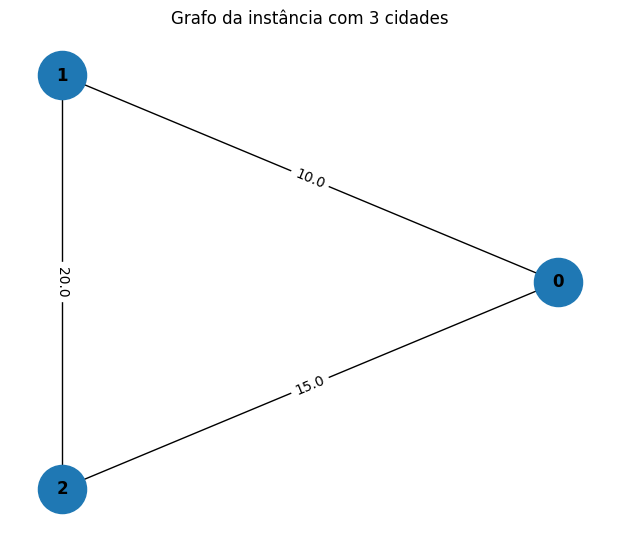

In [15]:
#Representação do grafo
grafo_3_cidades = nx.from_numpy_array(
    matriz_3_cidades
)

posicoes_3_cidades = nx.circular_layout(
    grafo_3_cidades
)

plt.figure(figsize=(6, 5))

nx.draw(
    grafo_3_cidades,
    pos=posicoes_3_cidades,
    with_labels=True,
    node_size=1200,
    font_weight="bold",
)

rotulos_arestas = nx.get_edge_attributes(
    grafo_3_cidades,
    "weight",
)

nx.draw_networkx_edge_labels(
    grafo_3_cidades,
    pos=posicoes_3_cidades,
    edge_labels=rotulos_arestas,
)

plt.title("Grafo da instância com 3 cidades")
plt.axis("off")
plt.show()

In [16]:
# Verificação das rotas possíveis
rotas_3_cidades = [
    (0, *permutacao)
    for permutacao in permutations([1, 2])
]

tabela_rotas_3 = pd.DataFrame(
    [
        {
            "Rota": " → ".join(
                map(str, (*rota, rota[0]))
            ),
            "Custo": calcular_custo_rota(
                rota,
                matriz_3_cidades,
            ),
        }
        for rota in rotas_3_cidades
    ]
)

tabela_rotas_3

,Rota,Custo
0,0 → 1 → 2 → 0,45.0
1,0 → 2 → 1 → 0,45.0


In [17]:
#Execução das abordagens clássica e quântica
resultado_3_cidades = executar_cenario(
    chave="3_cidades",
    instancia=INSTANCIAS_TSP["3_cidades"],
    profundidade=PROFUNDIDADE_QAOA,
    shots=NUMERO_SHOTS,
    maximo_iteracoes=MAXIMO_ITERACOES_OTIMIZADOR,
    semente=SEMENTE,
)

In [18]:
pd.DataFrame(
    [resultado_3_cidades["resumo"]]
)

,Cenário,Cidades,Qubits,Rota clássica,Custo clássico,Tempo clássico (s),Rota QAOA,Custo QAOA,Probabilidade da rota QAOA,Probabilidade de rota válida,Diferença relativa,Tempo QAOA (s),Profundidade do circuito,Operações do circuito
0,Cenário 1: 3 cidades,3,1,0 → 1 → 2 → 0,45.0,0.000025,0 → 1 → 2 → 0,45.0,0.50293,1.0,0.0,0.269238,2,2


In [19]:
resultado_classico_3 = resultado_3_cidades["classico"]
resultado_qaoa_3 = resultado_3_cidades["qaoa"]

print("RESULTADO CLÁSSICO")
print(
    "Rota:",
    " → ".join(
        map(
            str,
            (
                *resultado_classico_3["rota"],
                resultado_classico_3["rota"][0],
            ),
        )
    ),
)
print(
    f"Custo: {resultado_classico_3['custo']:.2f}"
)
print(
    f"Rotas avaliadas: "
    f"{resultado_classico_3['rotas_avaliadas']}"
)
print(
    f"Tempo: "
    f"{resultado_classico_3['tempo_segundos']:.8f} s"
)

print("\nRESULTADO QAOA")

if resultado_qaoa_3["rota"] is not None:
    print(
        "Rota mais frequente:",
        " → ".join(
            map(
                str,
                (
                    *resultado_qaoa_3["rota"],
                    resultado_qaoa_3["rota"][0],
                ),
            )
        ),
    )
else:
    print("Rota mais frequente: nenhuma rota válida")

print(
    f"Custo: {resultado_qaoa_3['custo']:.2f}"
)
print(
    f"Bitstring: {resultado_qaoa_3['bitstring']}"
)
print(
    f"Probabilidade da rota selecionada: "
    f"{resultado_qaoa_3['probabilidade_solucao']:.6f}"
)
print(
    f"Probabilidade de medir uma rota válida: "
    f"{resultado_qaoa_3['probabilidade_valida']:.6f}"
)
print(
    f"Valor esperado: "
    f"{resultado_qaoa_3['valor_esperado']:.6f}"
)
print(
    f"Tempo: "
    f"{resultado_qaoa_3['tempo_segundos']:.6f} s"
)

RESULTADO CLÁSSICO
Rota: 0 → 1 → 2 → 0
Custo: 45.00
Rotas avaliadas: 1
Tempo: 0.00002520 s

RESULTADO QAOA
Rota mais frequente: 0 → 1 → 2 → 0
Custo: 45.00
Bitstring: 0
Probabilidade da rota selecionada: 0.502930
Probabilidade de medir uma rota válida: 1.000000
Valor esperado: 45.000000
Tempo: 0.269238 s


In [20]:
#Hamiltoniano da instância
dados_hamiltoniano_3 = construir_hamiltoniano_tsp(
    matriz_3_cidades
)

print(
    "Número de qubits:",
    dados_hamiltoniano_3["numero_qubits"],
)

print(
    "Custos associados aos estados:",
    dados_hamiltoniano_3["energias"],
)

print("\nHamiltoniano:")
print(
    dados_hamiltoniano_3["hamiltoniano"]
)

Número de qubits: 1
Custos associados aos estados: [45. 45.]

Hamiltoniano:
SparsePauliOp(['I'],
              coeffs=[45.+0.j])


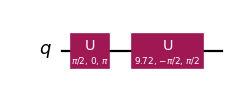

In [21]:
# Circuito do QAOA
from IPython.display import display

figura_circuito_3 = resultado_qaoa_3["circuito"].draw(
    output="mpl",
    fold=-1,
    scale=0.8,
)

display(figura_circuito_3)

In [22]:
print(
    "Número de qubits:",
    resultado_qaoa_3["numero_qubits"],
)

print(
    "Profundidade do circuito:",
    resultado_qaoa_3["profundidade_circuito"],
)

print(
    "Número de operações:",
    resultado_qaoa_3["numero_operacoes"],
)

print(
    "Parâmetros encontrados:",
    resultado_qaoa_3["parametros"],
)

Número de qubits: 1
Profundidade do circuito: 2
Número de operações: 2
Parâmetros encontrados: [4.86240927]


In [23]:
#Histograma das medições
figura_histograma_3 = plot_histogram(
    resultado_qaoa_3["contagens"],
    title="Distribuição das medições — 3 cidades",
)

plt.show()

In [24]:
#Probabilidade total de medir uma solução ótima
probabilidade_otima_3 = 0.0

for bitstring, contagem in resultado_qaoa_3[
    "contagens"
].items():
    indice = int(bitstring, 2)

    if indice < len(
        dados_hamiltoniano_3["rotas"]
    ):
        custo_estado = dados_hamiltoniano_3[
            "custos"
        ][indice]

        if np.isclose(
            custo_estado,
            resultado_classico_3["custo"],
        ):
            probabilidade_otima_3 += (
                contagem / NUMERO_SHOTS
            )

print(
    "Probabilidade total de medir uma solução ótima:",
    f"{probabilidade_otima_3:.6f}",
)

Probabilidade total de medir uma solução ótima: 1.000000


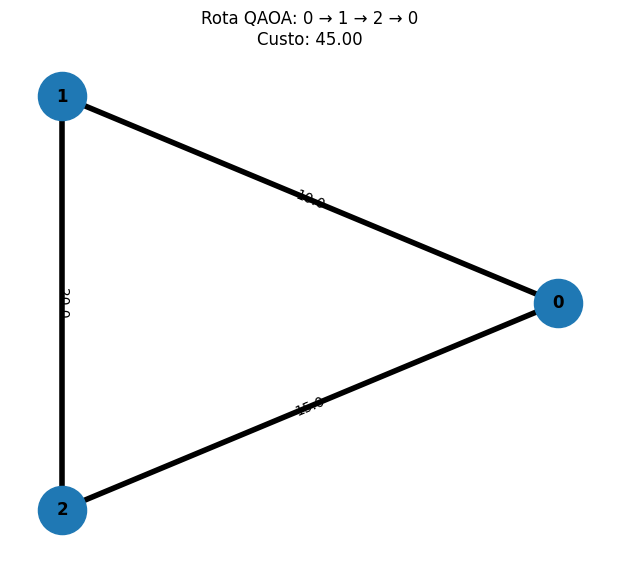

In [25]:
# Representação da rota encontrada pelo QAOA
rota_qaoa_3 = resultado_qaoa_3["rota"]

if rota_qaoa_3 is not None:
    arestas_rota_qaoa_3 = [
        (
            rota_qaoa_3[posicao],
            rota_qaoa_3[
                (posicao + 1)
                % len(rota_qaoa_3)
            ],
        )
        for posicao in range(
            len(rota_qaoa_3)
        )
    ]

    plt.figure(figsize=(6, 5))

    nx.draw(
        grafo_3_cidades,
        pos=posicoes_3_cidades,
        with_labels=True,
        node_size=1200,
        font_weight="bold",
    )

    nx.draw_networkx_edge_labels(
        grafo_3_cidades,
        pos=posicoes_3_cidades,
        edge_labels=rotulos_arestas,
    )

    nx.draw_networkx_edges(
        grafo_3_cidades,
        pos=posicoes_3_cidades,
        edgelist=arestas_rota_qaoa_3,
        width=4,
    )

    rota_texto_3 = " → ".join(
        map(
            str,
            (
                *rota_qaoa_3,
                rota_qaoa_3[0],
            ),
        )
    )

    plt.title(
        f"Rota QAOA: {rota_texto_3}\n"
        f"Custo: {resultado_qaoa_3['custo']:.2f}"
    )

    plt.axis("off")
    plt.show()

### Cenário 1: Análise dos resultados

Na instância com três cidades, a solução clássica identificou a rota:

$$
0 \rightarrow 1 \rightarrow 2 \rightarrow 0
$$

com custo total igual a:

$$
10 + 20 + 15 = 45
$$

A rota inversa:

$$
0 \rightarrow 2 \rightarrow 1 \rightarrow 0
$$

também possui custo igual a $45$. Como a matriz de distâncias é simétrica, as duas rotas representam o mesmo ciclo percorrido em sentidos opostos.

A solução clássica avaliou apenas uma rota devido à redução de simetria adotada. O tempo de execução foi de aproximadamente:

$$
1{,}57 \times 10^{-5}\ \text{s}
$$

A codificação quântica utilizou um qubit, pois as duas rotas possíveis podem ser representadas pelos estados $|0\rangle$ e $|1\rangle$. Como ambos os estados possuem custo igual a $45$, o Hamiltoniano de custo resultou em:

$$
H_C = 45I
$$

Isso significa que o Hamiltoniano atribui a mesma energia aos dois estados computacionais. Portanto, não existe uma rota melhor a ser favorecida pelo QAOA nessa instância.

O valor esperado obtido foi:

$$
\langle H_C \rangle = 45
$$

Esse valor permanece constante para qualquer estado normalizado, pois o Hamiltoniano é proporcional à identidade:

$$
\langle\psi|45I|\psi\rangle
=
45\langle\psi|\psi\rangle
=
45
$$

Consequentemente, o parâmetro associado ao operador de custo não influencia a distribuição das medições, pois sua aplicação produz apenas uma fase global. Por esse motivo, o circuito final apresentou somente um parâmetro efetivo, associado à operação de mistura.

Após $1024$ shots, a bitstring $0$, correspondente à rota:

$$
0 \rightarrow 1 \rightarrow 2 \rightarrow 0
$$

foi a mais frequente, com probabilidade observada de aproximadamente:

$$
0{,}502930
$$

A bitstring restante corresponde à rota inversa e recebeu a parcela restante das medições. A pequena diferença entre as frequências decorre da amostragem finita e não representa diferença de qualidade entre as soluções.

A probabilidade total de medir uma rota válida foi:

$$
P(\text{rota válida}) = 1{,}0
$$

Como as duas rotas são ótimas, a probabilidade total de medir uma solução ótima também foi:

$$
P(\text{solução ótima}) = 1{,}0
$$

O custo encontrado pelo QAOA foi igual ao ótimo clássico, resultando em diferença relativa nula:

$$
\frac{45-45}{45}=0
$$

O circuito utilizado apresentou profundidade igual a $2$ e apenas duas operações. O tempo de execução da simulação QAOA foi de aproximadamente $0{,}0305$ segundos, superior ao tempo da busca clássica nessa instância pequena. Esse valor representa o tempo de uma simulação clássica do circuito quântico e não deve ser interpretado como tempo de execução em um computador quântico físico.

Portanto, o Cenário 1 confirmou que a implementação clássica e a implementação baseada em QAOA produzem soluções de custo ótimo. Entretanto, devido à equivalência entre todas as rotas disponíveis, essa instância funciona principalmente como uma validação inicial do código e da codificação utilizada, não permitindo avaliar a capacidade do QAOA de favorecer uma rota de custo inferior.

## 9. Cenário 2: 4 cidades

No segundo cenário, o Problema do Caixeiro Viajante será resolvido para uma instância com quatro cidades.

A matriz de distâncias utilizada é:

$$
D =
\begin{bmatrix}
0 & 1 & 50 & 50 \\
1 & 0 & 2 & 50 \\
50 & 2 & 0 & 3 \\
50 & 50 & 3 & 0
\end{bmatrix}
$$

Os valores iguais a $50$ representam conexões de custo elevado. Essas arestas serão mantidas na instância, pois continuam sendo caminhos possíveis e são necessárias para completar algumas rotas.

Com a cidade $0$ fixada como origem, existem:

$$
(4-1)! = 6
$$

rotas possíveis. Como a matriz é simétrica, cada rota possui uma rota inversa de mesmo custo. Na solução clássica, essa simetria será utilizada para reduzir a quantidade de rotas avaliadas. Na codificação quântica, as seis rotas serão mantidas como estados distintos.

Neste cenário, serão avaliados:

- a rota ótima clássica;
- o custo de todas as rotas;
- o Hamiltoniano de custo;
- a quantidade de qubits utilizada;
- o circuito QAOA;
- a distribuição das medições;
- a rota mais frequente encontrada pelo QAOA;
- a probabilidade de medir uma rota válida;
- a probabilidade de medir uma solução ótima;
- os tempos de execução.

In [26]:
# Matriz de distâncias
matriz_4_cidades = INSTANCIAS_TSP["4_cidades"]["matriz"]

tabela_matriz_4 = pd.DataFrame(
    matriz_4_cidades,
    index=[
        "Cidade 0",
        "Cidade 1",
        "Cidade 2",
        "Cidade 3",
    ],
    columns=[
        "Cidade 0",
        "Cidade 1",
        "Cidade 2",
        "Cidade 3",
    ],
)

tabela_matriz_4

,Cidade 0,Cidade 1,Cidade 2,Cidade 3
Cidade 0,0.0,1.0,50.0,50.0
Cidade 1,1.0,0.0,2.0,50.0
Cidade 2,50.0,2.0,0.0,3.0
Cidade 3,50.0,50.0,3.0,0.0


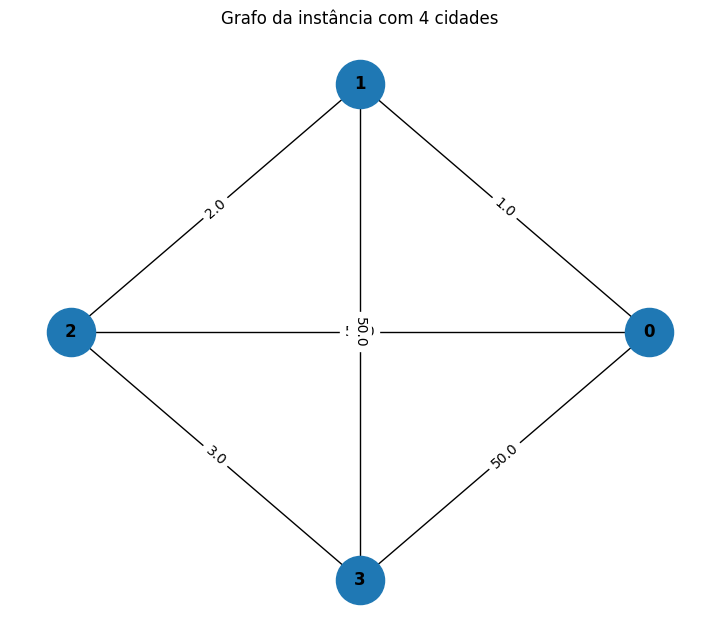

In [27]:
#Representação do grafo
grafo_4_cidades = nx.from_numpy_array(
    matriz_4_cidades
)

posicoes_4_cidades = nx.circular_layout(
    grafo_4_cidades
)

plt.figure(figsize=(7, 6))

nx.draw(
    grafo_4_cidades,
    pos=posicoes_4_cidades,
    with_labels=True,
    node_size=1200,
    font_weight="bold",
)

rotulos_arestas_4 = nx.get_edge_attributes(
    grafo_4_cidades,
    "weight",
)

nx.draw_networkx_edge_labels(
    grafo_4_cidades,
    pos=posicoes_4_cidades,
    edge_labels=rotulos_arestas_4,
)

plt.title("Grafo da instância com 4 cidades")
plt.axis("off")
plt.show()

In [28]:
#Rotas possíveis e respectivos custos
rotas_4_cidades = [
    (0, *permutacao)
    for permutacao in permutations([1, 2, 3])
]

tabela_rotas_4 = pd.DataFrame(
    [
        {
            "Índice": indice,
            "Bitstring": format(
                indice,
                "03b",
            ),
            "Rota": " → ".join(
                map(str, (*rota, rota[0]))
            ),
            "Custo": calcular_custo_rota(
                rota,
                matriz_4_cidades,
            ),
        }
        for indice, rota in enumerate(rotas_4_cidades)
    ]
)

tabela_rotas_4

,Índice,Bitstring,Rota,Custo
0,0,000,0 → 1 → 2 → 3 → 0,56.0
1,1,001,0 → 1 → 3 → 2 → 0,104.0
2,2,010,0 → 2 → 1 → 3 → 0,152.0
3,3,011,0 → 2 → 3 → 1 → 0,104.0
4,4,100,0 → 3 → 1 → 2 → 0,152.0
5,5,101,0 → 3 → 2 → 1 → 0,56.0


In [29]:
#Execução das abordagens clássica e quântica
resultado_4_cidades = executar_cenario(
    chave="4_cidades",
    instancia=INSTANCIAS_TSP["4_cidades"],
    profundidade=PROFUNDIDADE_QAOA,
    shots=NUMERO_SHOTS,
    maximo_iteracoes=MAXIMO_ITERACOES_OTIMIZADOR,
    semente=SEMENTE,
)

In [30]:
#Resumo dos resultados
pd.DataFrame(
    [resultado_4_cidades["resumo"]]
)

,Cenário,Cidades,Qubits,Rota clássica,Custo clássico,Tempo clássico (s),Rota QAOA,Custo QAOA,Probabilidade da rota QAOA,Probabilidade de rota válida,Diferença relativa,Tempo QAOA (s),Profundidade do circuito,Operações do circuito
0,Cenário 2: 4 cidades,4,3,0 → 1 → 2 → 3 → 0,56.0,0.000026,0 → 2 → 3 → 1 → 0,104.0,0.237305,0.873047,0.857143,0.427485,14,20


In [31]:
resultado_classico_4 = resultado_4_cidades["classico"]
resultado_qaoa_4 = resultado_4_cidades["qaoa"]

print("RESULTADO CLÁSSICO")

print(
    "Rota:",
    " → ".join(
        map(
            str,
            (
                *resultado_classico_4["rota"],
                resultado_classico_4["rota"][0],
            ),
        )
    ),
)

print(
    f"Custo: {resultado_classico_4['custo']:.2f}"
)

print(
    f"Rotas avaliadas: "
    f"{resultado_classico_4['rotas_avaliadas']}"
)

print(
    f"Tempo: "
    f"{resultado_classico_4['tempo_segundos']:.8f} s"
)

print("\nRESULTADO QAOA")

if resultado_qaoa_4["rota"] is not None:
    print(
        "Rota mais frequente:",
        " → ".join(
            map(
                str,
                (
                    *resultado_qaoa_4["rota"],
                    resultado_qaoa_4["rota"][0],
                ),
            )
        ),
    )
else:
    print("Rota mais frequente: nenhuma rota válida")

print(
    f"Custo: {resultado_qaoa_4['custo']:.2f}"
)

print(
    f"Bitstring: {resultado_qaoa_4['bitstring']}"
)

print(
    f"Probabilidade da rota selecionada: "
    f"{resultado_qaoa_4['probabilidade_solucao']:.6f}"
)

print(
    f"Probabilidade de medir uma rota válida: "
    f"{resultado_qaoa_4['probabilidade_valida']:.6f}"
)

print(
    f"Valor esperado: "
    f"{resultado_qaoa_4['valor_esperado']:.6f}"
)

print(
    f"Tempo: "
    f"{resultado_qaoa_4['tempo_segundos']:.6f} s"
)

RESULTADO CLÁSSICO
Rota: 0 → 1 → 2 → 3 → 0
Custo: 56.00
Rotas avaliadas: 3
Tempo: 0.00002630 s

RESULTADO QAOA
Rota mais frequente: 0 → 2 → 3 → 1 → 0
Custo: 104.00
Bitstring: 011
Probabilidade da rota selecionada: 0.237305
Probabilidade de medir uma rota válida: 0.873047
Valor esperado: 133.028362
Tempo: 0.427485 s


In [32]:
#Hamiltoniano da instância
dados_hamiltoniano_4 = construir_hamiltoniano_tsp(
    matriz_4_cidades
)

print(
    "Número de rotas:",
    len(dados_hamiltoniano_4["rotas"]),
)

print(
    "Número de qubits:",
    dados_hamiltoniano_4["numero_qubits"],
)

print(
    "Número de estados computacionais:",
    dados_hamiltoniano_4["numero_estados"],
)

print(
    "Penalidade:",
    dados_hamiltoniano_4["penalidade"],
)

print(
    "Energias associadas aos estados:",
    dados_hamiltoniano_4["energias"],
)

print("\nHamiltoniano:")
print(
    dados_hamiltoniano_4["hamiltoniano"]
)

Número de rotas: 6
Número de qubits: 3
Número de estados computacionais: 8
Penalidade: 352.0
Energias associadas aos estados: [ 56. 104. 152. 104. 152.  56. 352. 352.]

Hamiltoniano:
SparsePauliOp(['III', 'IIZ', 'IZI', 'ZII', 'ZIZ', 'ZZI', 'ZZZ'],
              coeffs=[166.+0.j,  12.+0.j, -74.+0.j, -62.+0.j, -12.+0.j,  50.+0.j, -24.+0.j])


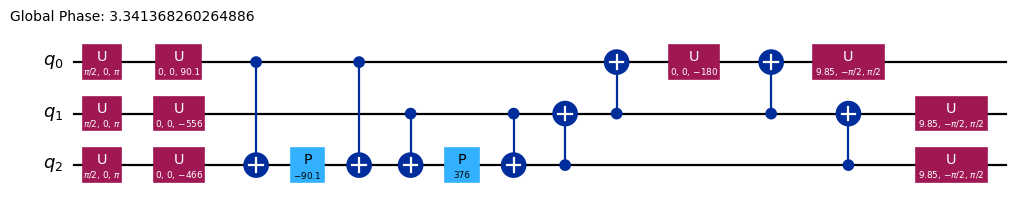

In [33]:
#Circuito do QAOA
from IPython.display import display

figura_circuito_4 = resultado_qaoa_4["circuito"].draw(
    output="mpl",
    fold=-1,
    scale=0.8,
)

display(figura_circuito_4)

In [34]:
print(
    "Número de qubits:",
    resultado_qaoa_4["numero_qubits"],
)

print(
    "Profundidade do circuito:",
    resultado_qaoa_4["profundidade_circuito"],
)

print(
    "Número de operações:",
    resultado_qaoa_4["numero_operacoes"],
)

print(
    "Parâmetros encontrados:",
    resultado_qaoa_4["parametros"],
)

print(
    "Otimização concluída:",
    resultado_qaoa_4["sucesso_otimizador"],
)

print(
    "Mensagem do otimizador:",
    resultado_qaoa_4["mensagem_otimizador"],
)

Número de qubits: 3
Profundidade do circuito: 14
Número de operações: 20
Parâmetros encontrados: [4.92593679 3.75512379]
Otimização concluída: False
Mensagem do otimizador: Return from COBYLA because the objective function has been evaluated MAXFUN times.


In [35]:
#Histograma das medições
figura_histograma_4 = plot_histogram(
    resultado_qaoa_4["contagens"],
    title="Distribuição das medições — 4 cidades",
)

plt.show()

In [36]:
#Probabilidade de medir uma solução ótima
probabilidade_otima_4 = 0.0

for bitstring, contagem in resultado_qaoa_4[
    "contagens"
].items():
    indice = int(bitstring, 2)

    if indice < len(
        dados_hamiltoniano_4["rotas"]
    ):
        custo_estado = dados_hamiltoniano_4[
            "custos"
        ][indice]

        if np.isclose(
            custo_estado,
            resultado_classico_4["custo"],
        ):
            probabilidade_otima_4 += (
                contagem / NUMERO_SHOTS
            )

print(
    "Probabilidade total de medir uma solução ótima:",
    f"{probabilidade_otima_4:.6f}",
)

Probabilidade total de medir uma solução ótima: 0.337891


In [37]:
#Tabela das medições
linhas_medicoes_4 = []

for bitstring, contagem in sorted(
    resultado_qaoa_4["contagens"].items()
):
    indice = int(bitstring, 2)

    if indice < len(
        dados_hamiltoniano_4["rotas"]
    ):
        rota = dados_hamiltoniano_4[
            "rotas"
        ][indice]

        custo = dados_hamiltoniano_4[
            "custos"
        ][indice]

        rota_texto = " → ".join(
            map(str, (*rota, rota[0]))
        )

        tipo_estado = (
            "Ótima"
            if np.isclose(
                custo,
                resultado_classico_4["custo"],
            )
            else "Válida"
        )
    else:
        rota_texto = "Sem rota associada"
        custo = dados_hamiltoniano_4["penalidade"]
        tipo_estado = "Inválida"

    linhas_medicoes_4.append(
        {
            "Bitstring": bitstring,
            "Índice": indice,
            "Rota": rota_texto,
            "Custo ou energia": custo,
            "Classificação": tipo_estado,
            "Contagens": contagem,
            "Probabilidade": contagem / NUMERO_SHOTS,
        }
    )

tabela_medicoes_4 = pd.DataFrame(
    linhas_medicoes_4
)

tabela_medicoes_4.sort_values(
    by="Contagens",
    ascending=False,
)

,Bitstring,Índice,Rota,Custo ou energia,Classificação,Contagens,Probabilidade
3,011,3,0 → 2 → 3 → 1 → 0,104.0,Válida,243,0.237305
0,000,0,0 → 1 → 2 → 3 → 0,56.0,Ótima,198,0.193359
5,101,5,0 → 3 → 2 → 1 → 0,56.0,Ótima,148,0.144531
2,010,2,0 → 2 → 1 → 3 → 0,152.0,Válida,127,0.124023
4,100,4,0 → 3 → 1 → 2 → 0,152.0,Válida,107,0.104492
7,111,7,Sem rota associada,352.0,Inválida,88,0.085938
1,001,1,0 → 1 → 3 → 2 → 0,104.0,Válida,71,0.069336
6,110,6,Sem rota associada,352.0,Inválida,42,0.041016


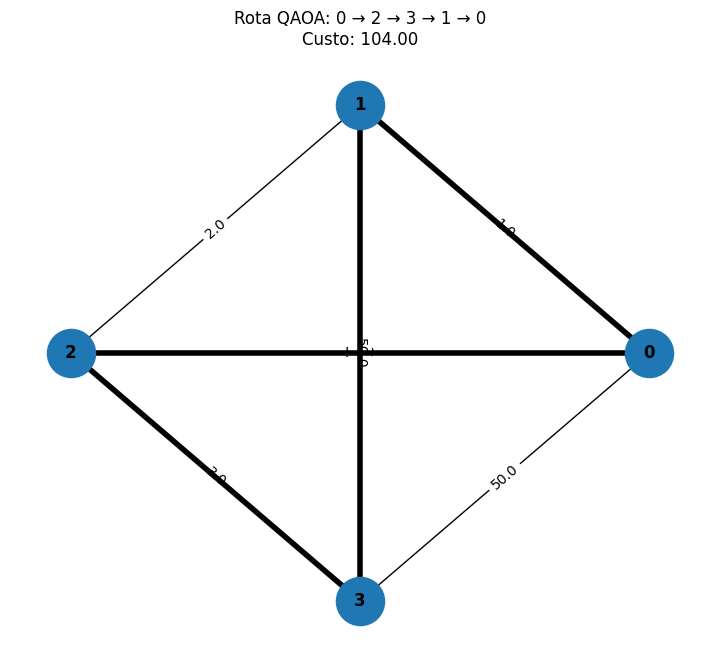

In [38]:
#Representação da rota encotrada pelo QAOA
rota_qaoa_4 = resultado_qaoa_4["rota"]

if rota_qaoa_4 is not None:
    arestas_rota_qaoa_4 = [
        (
            rota_qaoa_4[posicao],
            rota_qaoa_4[
                (posicao + 1)
                % len(rota_qaoa_4)
            ],
        )
        for posicao in range(
            len(rota_qaoa_4)
        )
    ]

    plt.figure(figsize=(7, 6))

    nx.draw(
        grafo_4_cidades,
        pos=posicoes_4_cidades,
        with_labels=True,
        node_size=1200,
        font_weight="bold",
    )

    nx.draw_networkx_edge_labels(
        grafo_4_cidades,
        pos=posicoes_4_cidades,
        edge_labels=rotulos_arestas_4,
    )

    nx.draw_networkx_edges(
        grafo_4_cidades,
        pos=posicoes_4_cidades,
        edgelist=arestas_rota_qaoa_4,
        width=4,
    )

    rota_texto_4 = " → ".join(
        map(
            str,
            (
                *rota_qaoa_4,
                rota_qaoa_4[0],
            ),
        )
    )

    plt.title(
        f"Rota QAOA: {rota_texto_4}\n"
        f"Custo: {resultado_qaoa_4['custo']:.2f}"
    )

    plt.axis("off")
    plt.show()

## 10. Cenário 3: 5 cidades

No terceiro cenário, o Problema do Caixeiro Viajante será resolvido para uma instância com cinco cidades.

A matriz de distâncias utilizada é:

$$
D =
\begin{bmatrix}
0 & 2 & 9 & 10 & 7 \\
2 & 0 & 6 & 4 & 3 \\
9 & 6 & 0 & 8 & 5 \\
10 & 4 & 8 & 0 & 6 \\
7 & 3 & 5 & 6 & 0
\end{bmatrix}
$$

Com a cidade 0 fixada como origem, a quantidade de rotas possíveis é:

$$
(5-1)! = 24
$$

Para representar 24 rotas, são necessários:

$$
\left\lceil \log_2 24 \right\rceil = 5
$$

qubits. Cinco qubits representam 32 estados computacionais. Portanto, 24 estados serão associados a rotas válidas e os 8 estados restantes receberão uma penalidade no Hamiltoniano de custo.

Neste cenário, serão comparadas a solução clássica exata e a solução obtida pelo QAOA, considerando a rota encontrada, o custo, o tempo de execução, a probabilidade de soluções válidas e a probabilidade de medir uma rota ótima.

In [39]:
# Matriz de distâncias
matriz_5_cidades = INSTANCIAS_TSP["5_cidades"]["matriz"]

tabela_matriz_5 = pd.DataFrame(
    matriz_5_cidades,
    index=[f"Cidade {i}" for i in range(5)],
    columns=[f"Cidade {i}" for i in range(5)],
)

tabela_matriz_5

,Cidade 0,Cidade 1,Cidade 2,Cidade 3,Cidade 4
Cidade 0,0.0,2.0,9.0,10.0,7.0
Cidade 1,2.0,0.0,6.0,4.0,3.0
Cidade 2,9.0,6.0,0.0,8.0,5.0
Cidade 3,10.0,4.0,8.0,0.0,6.0
Cidade 4,7.0,3.0,5.0,6.0,0.0


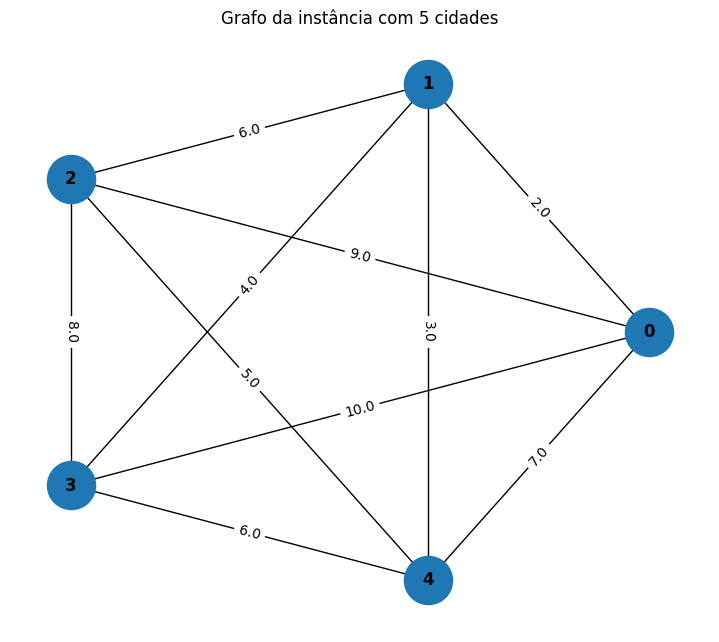

In [40]:
#Representação do grafo
grafo_5_cidades = nx.from_numpy_array(
    matriz_5_cidades
)

posicoes_5_cidades = nx.circular_layout(
    grafo_5_cidades
)

plt.figure(figsize=(7, 6))

nx.draw(
    grafo_5_cidades,
    pos=posicoes_5_cidades,
    with_labels=True,
    node_size=1200,
    font_weight="bold",
)

rotulos_arestas_5 = nx.get_edge_attributes(
    grafo_5_cidades,
    "weight",
)

nx.draw_networkx_edge_labels(
    grafo_5_cidades,
    pos=posicoes_5_cidades,
    edge_labels=rotulos_arestas_5,
)

plt.title("Grafo da instância com 5 cidades")
plt.axis("off")
plt.show()

In [41]:
#Rotas possíveis e respectivos custos
rotas_5_cidades = [
    (0, *permutacao)
    for permutacao in permutations([1, 2, 3, 4])
]

tabela_rotas_5 = pd.DataFrame(
    [
        {
            "Índice": indice,
            "Bitstring": format(indice, "05b"),
            "Rota": " → ".join(
                map(str, (*rota, rota[0]))
            ),
            "Custo": calcular_custo_rota(
                rota,
                matriz_5_cidades,
            ),
        }
        for indice, rota in enumerate(rotas_5_cidades)
    ]
)

tabela_rotas_5 = tabela_rotas_5.sort_values(
    by=["Custo", "Índice"]
).reset_index(drop=True)

tabela_rotas_5

,Índice,Bitstring,Rota,Custo
0,2,00010,0 → 1 → 3 → 2 → 4 → 0,26.0
1,3,00011,0 → 1 → 3 → 4 → 2 → 0,26.0
2,11,01011,0 → 2 → 4 → 3 → 1 → 0,26.0
3,21,10101,0 → 4 → 2 → 3 → 1 → 0,26.0
4,4,00100,0 → 1 → 4 → 2 → 3 → 0,28.0
5,5,00101,0 → 1 → 4 → 3 → 2 → 0,28.0
6,9,01001,0 → 2 → 3 → 4 → 1 → 0,28.0
7,15,01111,0 → 3 → 2 → 4 → 1 → 0,28.0
8,0,00000,0 → 1 → 2 → 3 → 4 → 0,29.0
9,1,00001,0 → 1 → 2 → 4 → 3 → 0,29.0


In [42]:
#Execução das abordagens clássica e quântica
resultado_5_cidades = executar_cenario(
    chave="5_cidades",
    instancia=INSTANCIAS_TSP["5_cidades"],
    profundidade=PROFUNDIDADE_QAOA,
    shots=NUMERO_SHOTS,
    maximo_iteracoes=MAXIMO_ITERACOES_OTIMIZADOR,
    semente=SEMENTE,
)

In [43]:
#Resumo dos resultados
pd.DataFrame(
    [resultado_5_cidades["resumo"]]
)

,Cenário,Cidades,Qubits,Rota clássica,Custo clássico,Tempo clássico (s),Rota QAOA,Custo QAOA,Probabilidade da rota QAOA,Probabilidade de rota válida,Diferença relativa,Tempo QAOA (s),Profundidade do circuito,Operações do circuito
0,Cenário 3: 5 cidades,5,5,0 → 1 → 3 → 2 → 4 → 0,26.0,0.000047,0 → 4 → 1 → 3 → 2 → 0,31.0,0.088867,0.859375,0.192308,1.558731,109,123


In [44]:
resultado_classico_5 = resultado_5_cidades["classico"]
resultado_qaoa_5 = resultado_5_cidades["qaoa"]

rota_classica_5 = " → ".join(
    map(
        str,
        (
            *resultado_classico_5["rota"],
            resultado_classico_5["rota"][0],
        ),
    )
)

print("RESULTADO CLÁSSICO")
print(f"Rota: {rota_classica_5}")
print(f"Custo: {resultado_classico_5['custo']:.2f}")
print(
    "Rotas avaliadas:",
    resultado_classico_5["rotas_avaliadas"],
)
print(
    f"Tempo: "
    f"{resultado_classico_5['tempo_segundos']:.8f} s"
)

print("\nRESULTADO QAOA")

if resultado_qaoa_5["rota"] is not None:
    rota_qaoa_texto_5 = " → ".join(
        map(
            str,
            (
                *resultado_qaoa_5["rota"],
                resultado_qaoa_5["rota"][0],
            ),
        )
    )

    print(f"Rota mais frequente: {rota_qaoa_texto_5}")
else:
    print("Rota mais frequente: nenhuma rota válida")

print(f"Custo: {resultado_qaoa_5['custo']:.2f}")
print(f"Bitstring: {resultado_qaoa_5['bitstring']}")
print(
    "Probabilidade da rota selecionada:",
    f"{resultado_qaoa_5['probabilidade_solucao']:.6f}",
)
print(
    "Probabilidade de medir uma rota válida:",
    f"{resultado_qaoa_5['probabilidade_valida']:.6f}",
)
print(
    "Valor esperado:",
    f"{resultado_qaoa_5['valor_esperado']:.6f}",
)
print(
    "Tempo:",
    f"{resultado_qaoa_5['tempo_segundos']:.6f} s",
)

RESULTADO CLÁSSICO
Rota: 0 → 1 → 3 → 2 → 4 → 0
Custo: 26.00
Rotas avaliadas: 12
Tempo: 0.00004700 s

RESULTADO QAOA
Rota mais frequente: 0 → 4 → 1 → 3 → 2 → 0
Custo: 31.00
Bitstring: 10011
Probabilidade da rota selecionada: 0.088867
Probabilidade de medir uma rota válida: 0.859375
Valor esperado: 36.990038
Tempo: 1.558731 s


In [45]:
#Hamiltoniano da instância
dados_hamiltoniano_5 = construir_hamiltoniano_tsp(
    matriz_5_cidades
)

print(
    "Número de rotas:",
    len(dados_hamiltoniano_5["rotas"]),
)

print(
    "Número de qubits:",
    dados_hamiltoniano_5["numero_qubits"],
)

print(
    "Número de estados computacionais:",
    dados_hamiltoniano_5["numero_estados"],
)

print(
    "Estados sem rota associada:",
    (
        dados_hamiltoniano_5["numero_estados"]
        - len(dados_hamiltoniano_5["rotas"])
    ),
)

print(
    "Penalidade:",
    dados_hamiltoniano_5["penalidade"],
)

print(
    "Número de termos de Pauli:",
    len(dados_hamiltoniano_5["hamiltoniano"]),
)

Número de rotas: 24
Número de qubits: 5
Número de estados computacionais: 32
Estados sem rota associada: 8
Penalidade: 84.0
Número de termos de Pauli: 28


In [46]:
print(
    "Energias associadas aos estados:\n",
    dados_hamiltoniano_5["energias"],
)

Energias associadas aos estados:
 [29. 29. 26. 26. 28. 28. 32. 34. 31. 28. 31. 26. 32. 31. 34. 28. 34. 29.
 34. 31. 32. 26. 32. 29. 84. 84. 84. 84. 84. 84. 84. 84.]


In [47]:
#Recursos e parâmetros do circuito
print(
    "Número de qubits:",
    resultado_qaoa_5["numero_qubits"],
)

print(
    "Profundidade do circuito:",
    resultado_qaoa_5["profundidade_circuito"],
)

print(
    "Número de operações:",
    resultado_qaoa_5["numero_operacoes"],
)

print(
    "Parâmetros encontrados:",
    resultado_qaoa_5["parametros"],
)

print(
    "Otimização concluída:",
    resultado_qaoa_5["sucesso_otimizador"],
)

print(
    "Mensagem do otimizador:",
    resultado_qaoa_5["mensagem_otimizador"],
)

Número de qubits: 5
Profundidade do circuito: 109
Número de operações: 123
Parâmetros encontrados: [5.9473176  2.52758843]
Otimização concluída: False
Mensagem do otimizador: Return from COBYLA because the objective function has been evaluated MAXFUN times.


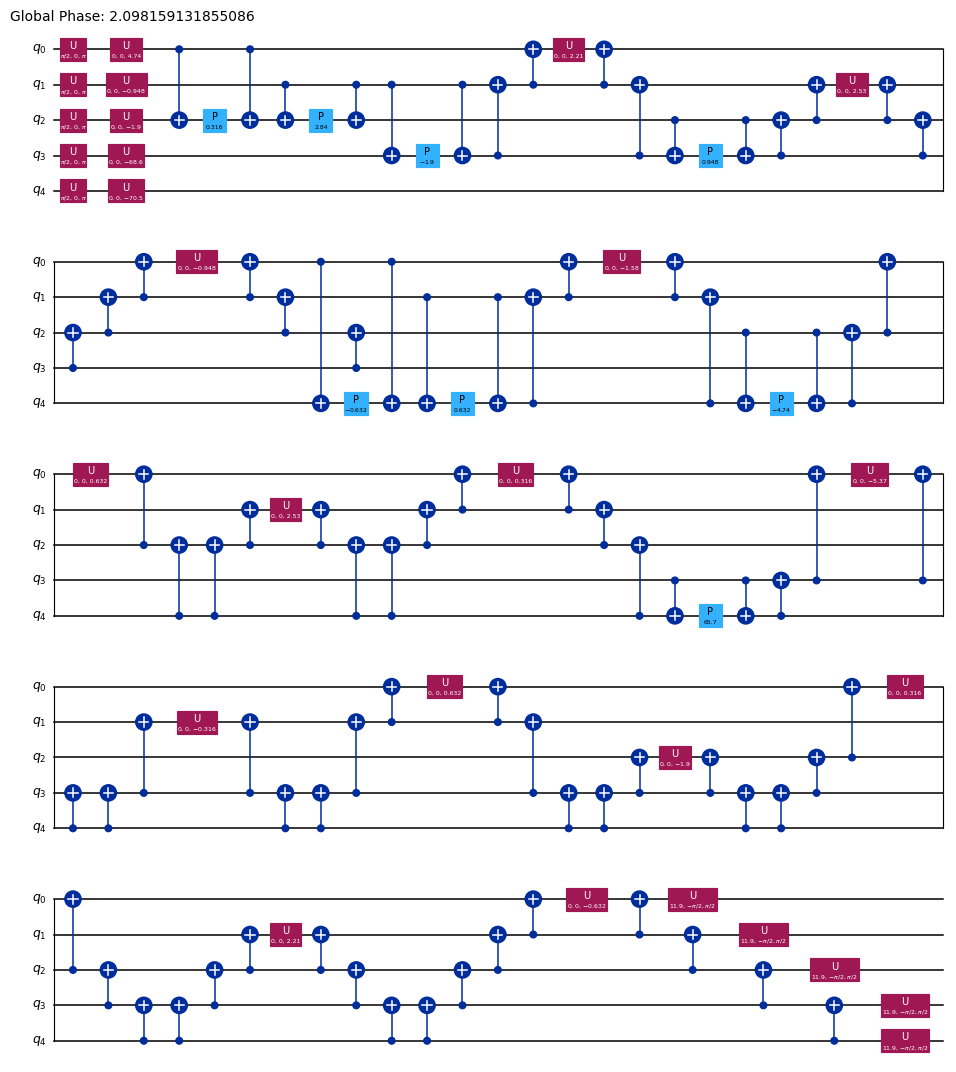

In [48]:
# Circuito do QAOA
from IPython.display import display

figura_circuito_5 = resultado_qaoa_5["circuito"].draw(
    output="mpl",
    fold=25,
    scale=0.55,
)

display(figura_circuito_5)

In [49]:
#Histograma das medições
figura_histograma_5 = plot_histogram(
    resultado_qaoa_5["contagens"],
    title="Distribuição das medições — 5 cidades",
)

plt.show()

In [50]:
contagens_ordenadas_5 = dict(
    sorted(
        resultado_qaoa_5["contagens"].items(),
        key=lambda item: item[1],
        reverse=True,
    )[:15]
)

figura_histograma_top_5 = plot_histogram(
    contagens_ordenadas_5,
    title="15 estados mais frequentes — 5 cidades",
)

plt.show()

In [51]:
#Probabilidade de medir uma solução ótima
indices_otimos_5 = [
    indice
    for indice, custo in enumerate(
        dados_hamiltoniano_5["custos"]
    )
    if np.isclose(
        custo,
        resultado_classico_5["custo"],
    )
]

probabilidade_otima_5 = 0.0

for bitstring, contagem in resultado_qaoa_5[
    "contagens"
].items():
    indice = int(bitstring, 2)

    if indice in indices_otimos_5:
        probabilidade_otima_5 += (
            contagem / NUMERO_SHOTS
        )

print(
    "Índices das rotas ótimas:",
    indices_otimos_5,
)

print(
    "Bitstrings das rotas ótimas:",
    [
        format(indice, "05b")
        for indice in indices_otimos_5
    ],
)

print(
    "Probabilidade total de medir uma solução ótima:",
    f"{probabilidade_otima_5:.6f}",
)

Índices das rotas ótimas: [2, 3, 11, 21]
Bitstrings das rotas ótimas: ['00010', '00011', '01011', '10101']
Probabilidade total de medir uma solução ótima: 0.234375


In [52]:
for indice in indices_otimos_5:
    rota = dados_hamiltoniano_5["rotas"][indice]

    rota_texto = " → ".join(
        map(str, (*rota, rota[0]))
    )

    print(
        f"{format(indice, '05b')} | "
        f"{rota_texto} | "
        f"Custo: {dados_hamiltoniano_5['custos'][indice]:.2f}"
    )

00010 | 0 → 1 → 3 → 2 → 4 → 0 | Custo: 26.00
00011 | 0 → 1 → 3 → 4 → 2 → 0 | Custo: 26.00
01011 | 0 → 2 → 4 → 3 → 1 → 0 | Custo: 26.00
10101 | 0 → 4 → 2 → 3 → 1 → 0 | Custo: 26.00


In [53]:
#Tabela das medições mais frequentes
linhas_medicoes_5 = []

for bitstring, contagem in resultado_qaoa_5[
    "contagens"
].items():
    indice = int(bitstring, 2)

    if indice < len(
        dados_hamiltoniano_5["rotas"]
    ):
        rota = dados_hamiltoniano_5[
            "rotas"
        ][indice]

        custo = float(
            dados_hamiltoniano_5[
                "custos"
            ][indice]
        )

        rota_texto = " → ".join(
            map(str, (*rota, rota[0]))
        )

        classificacao = (
            "Ótima"
            if np.isclose(
                custo,
                resultado_classico_5["custo"],
            )
            else "Válida"
        )
    else:
        rota_texto = "Sem rota associada"
        custo = dados_hamiltoniano_5["penalidade"]
        classificacao = "Inválida"

    linhas_medicoes_5.append(
        {
            "Bitstring": bitstring,
            "Índice": indice,
            "Rota": rota_texto,
            "Custo ou energia": custo,
            "Classificação": classificacao,
            "Contagens": int(contagem),
            "Probabilidade": contagem / NUMERO_SHOTS,
        }
    )

tabela_medicoes_5 = pd.DataFrame(
    linhas_medicoes_5
).sort_values(
    by="Contagens",
    ascending=False,
).reset_index(drop=True)

tabela_medicoes_5.head(15)

,Bitstring,Índice,Rota,Custo ou energia,Classificação,Contagens,Probabilidade
0,10011,19,0 → 4 → 1 → 3 → 2 → 0,31.0,Válida,91,0.088867
1,00101,5,0 → 1 → 4 → 3 → 2 → 0,28.0,Válida,88,0.085938
2,01001,9,0 → 2 → 3 → 4 → 1 → 0,28.0,Válida,88,0.085938
3,01111,15,0 → 3 → 2 → 4 → 1 → 0,28.0,Válida,81,0.079102
4,00011,3,0 → 1 → 3 → 4 → 2 → 0,26.0,Ótima,76,0.074219
5,01010,10,0 → 2 → 4 → 1 → 3 → 0,31.0,Válida,70,0.068359
6,00010,2,0 → 1 → 3 → 2 → 4 → 0,26.0,Ótima,59,0.057617
7,10101,21,0 → 4 → 2 → 3 → 1 → 0,26.0,Ótima,56,0.054688
8,11100,28,Sem rota associada,84.0,Inválida,52,0.050781
9,11110,30,Sem rota associada,84.0,Inválida,49,0.047852


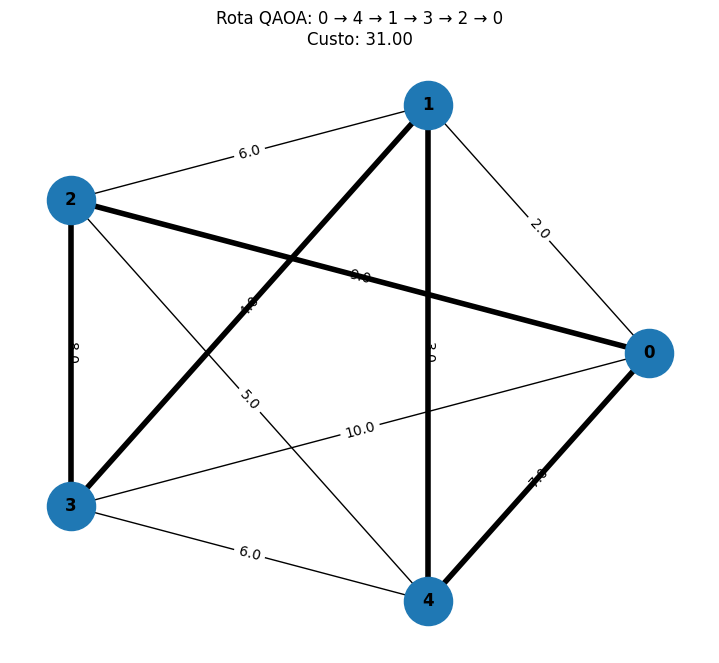

In [54]:
#Representação da rota encontrada pelo QAOA
rota_qaoa_5 = resultado_qaoa_5["rota"]

if rota_qaoa_5 is not None:
    arestas_rota_qaoa_5 = [
        (
            rota_qaoa_5[posicao],
            rota_qaoa_5[
                (posicao + 1)
                % len(rota_qaoa_5)
            ],
        )
        for posicao in range(
            len(rota_qaoa_5)
        )
    ]

    plt.figure(figsize=(7, 6))

    nx.draw(
        grafo_5_cidades,
        pos=posicoes_5_cidades,
        with_labels=True,
        node_size=1200,
        font_weight="bold",
    )

    nx.draw_networkx_edge_labels(
        grafo_5_cidades,
        pos=posicoes_5_cidades,
        edge_labels=rotulos_arestas_5,
    )

    nx.draw_networkx_edges(
        grafo_5_cidades,
        pos=posicoes_5_cidades,
        edgelist=arestas_rota_qaoa_5,
        width=4,
    )

    rota_texto_5 = " → ".join(
        map(
            str,
            (
                *rota_qaoa_5,
                rota_qaoa_5[0],
            ),
        )
    )

    plt.title(
        f"Rota QAOA: {rota_texto_5}\n"
        f"Custo: {resultado_qaoa_5['custo']:.2f}"
    )

    plt.axis("off")
    plt.show()

### Cenário 3:Análise dos resultados

Na instância com cinco cidades, a solução clássica exata avaliou 12 rotas distintas após a redução de simetria. A rota ótima identificada foi:

$$
0 \rightarrow 1 \rightarrow 3 \rightarrow 2 \rightarrow 4 \rightarrow 0
$$

com custo total igual a:

$$
26
$$

O tempo da busca clássica foi de aproximadamente:

$$
7{,}59 \times 10^{-5}\ \text{s}
$$

Na codificação quântica, foram mantidas todas as 24 rotas iniciadas na cidade 0. Para representar esses índices, foram necessários 5 qubits, correspondentes a 32 estados computacionais.

Desses estados, 24 representam rotas válidas e 8 não possuem rota associada. Os estados inválidos receberam energia igual a 84, valor superior ao custo de todas as rotas válidas.

O Hamiltoniano apresentou 28 termos de Pauli. O circuito decomposto apresentou profundidade igual a 109 e 123 operações, mostrando um crescimento significativo em relação ao cenário com quatro cidades.

O otimizador COBYLA encerrou a execução após atingir o número máximo de avaliações da função objetivo. Portanto, os parâmetros encontrados representam a melhor configuração obtida dentro do limite definido, mas o processo não apresentou uma declaração formal de convergência.

A rota válida individualmente mais frequente foi:

$$
0 \rightarrow 4 \rightarrow 1 \rightarrow 3 \rightarrow 2 \rightarrow 0
$$

associada à bitstring:

$$
10011
$$

Essa rota foi medida 91 vezes em 1024 shots, correspondendo à probabilidade:

$$
P(10011)
=
\frac{91}{1024}
\approx
0{,}088867
$$

Seu custo foi igual a 31. Em relação ao ótimo clássico, a diferença relativa foi:

$$
\frac{31-26}{26}
\approx
0{,}192308
$$

ou aproximadamente:

$$
19{,}23\%
$$

Entretanto, o QAOA também produziu quatro estados associados a soluções ótimas:

$$
00010,\quad 00011,\quad 01011,\quad 10101
$$

Esses estados correspondem a quatro representações direcionadas de duas rotas ótimas distintas, considerando também os percursos inversos.

A probabilidade total de medir uma solução ótima foi:

$$
P(\text{solução ótima})
=
0{,}234375
$$

Portanto, aproximadamente 23,44% das medições retornaram uma rota com custo igual ao ótimo clássico.

A probabilidade total de medir uma rota válida foi:

$$
P(\text{rota válida})
=
0{,}859375
$$

Consequentemente, a probabilidade de medir um estado sem rota associada foi:

$$
P(\text{estado inválido})
=
1-0{,}859375
=
0{,}140625
$$

O valor esperado final do Hamiltoniano foi aproximadamente:

$$
\langle H_C\rangle
=
36{,}990038
$$

Esse valor é superior ao custo ótimo porque o estado final ainda distribuiu probabilidade entre rotas subótimas e estados penalizados.

A execução do QAOA em simulador levou aproximadamente 0,70128 segundos, enquanto a busca clássica levou cerca de 0,0000759 segundo. Esses tempos não demonstram diretamente o desempenho de um processador quântico físico, pois o circuito quântico foi simulado por um computador clássico.

Os resultados mostram que, com profundidade $p=1$, o QAOA conseguiu produzir soluções ótimas, mas não concentrou a maior probabilidade individual em uma delas. A distribuição permaneceu espalhada entre rotas ótimas, rotas subótimas e estados inválidos.

Assim, o resultado deve ser interpretado de duas formas:

- a rota mais frequente foi subótima, com custo 31;
- a melhor rota amostrada foi ótima, com custo 26.

O cenário evidencia a natureza probabilística do QAOA e mostra que a análise não deve considerar apenas a bitstring mais frequente. Também é necessário verificar a qualidade das demais soluções presentes na distribuição de medições.

## 11. Cenário 4: 6 cidades

No quarto cenário, o Problema do Caixeiro Viajante será resolvido para uma instância com seis cidades.

A matriz de distâncias utilizada é:

$$
D =
\begin{bmatrix}
0 & 4 & 1 & 9 & 8 & 6 \\
4 & 0 & 3 & 5 & 2 & 7 \\
1 & 3 & 0 & 6 & 4 & 5 \\
9 & 5 & 6 & 0 & 3 & 2 \\
8 & 2 & 4 & 3 & 0 & 4 \\
6 & 7 & 5 & 2 & 4 & 0
\end{bmatrix}
$$

Com a cidade 0 fixada como origem, existem:

$$
(6-1)! = 120
$$

rotas possíveis.

Na solução clássica, a equivalência entre uma rota e seu percurso inverso reduz a quantidade de rotas avaliadas para:

$$
\frac{120}{2}=60
$$

Na codificação quântica, as 120 rotas serão mantidas como estados diferentes. A quantidade necessária de qubits é:

$$
\left\lceil \log_2 120 \right\rceil = 7
$$

Sete qubits representam:

$$
2^7=128
$$

estados computacionais. Portanto, 120 estados serão associados a rotas válidas e 8 estados receberão uma penalidade por não possuírem rota correspondente.

Este cenário permitirá observar o crescimento do Hamiltoniano, da profundidade do circuito, do número de operações e do tempo de simulação.

In [55]:
# Matriz de distâncias
matriz_6_cidades = INSTANCIAS_TSP["6_cidades"]["matriz"]

tabela_matriz_6 = pd.DataFrame(
    matriz_6_cidades,
    index=[f"Cidade {i}" for i in range(6)],
    columns=[f"Cidade {i}" for i in range(6)],
)

tabela_matriz_6

,Cidade 0,Cidade 1,Cidade 2,Cidade 3,Cidade 4,Cidade 5
Cidade 0,0.0,4.0,1.0,9.0,8.0,6.0
Cidade 1,4.0,0.0,3.0,5.0,2.0,7.0
Cidade 2,1.0,3.0,0.0,6.0,4.0,5.0
Cidade 3,9.0,5.0,6.0,0.0,3.0,2.0
Cidade 4,8.0,2.0,4.0,3.0,0.0,4.0
Cidade 5,6.0,7.0,5.0,2.0,4.0,0.0


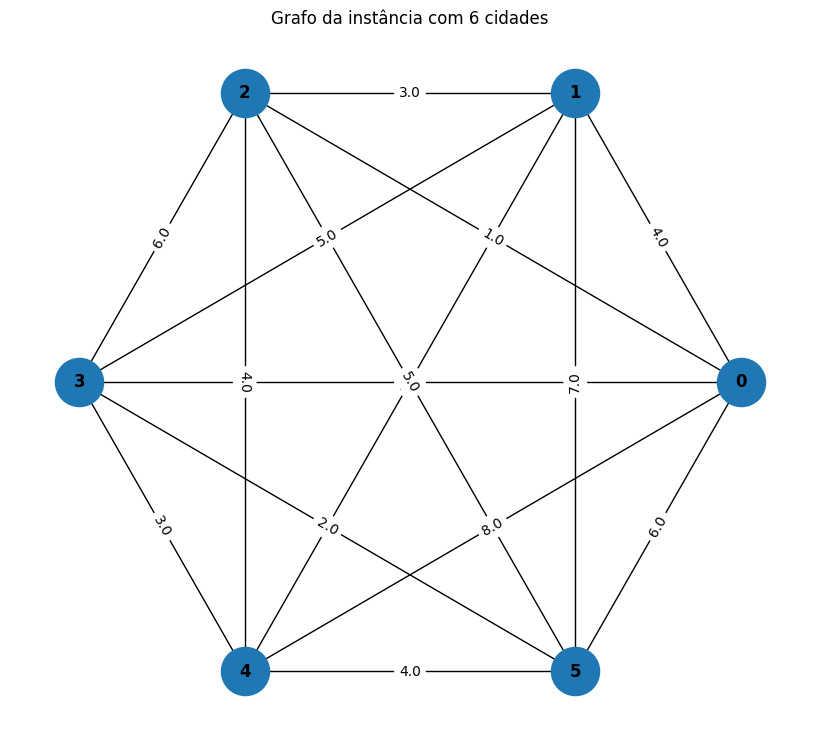

In [56]:
#Representação do grafo
grafo_6_cidades = nx.from_numpy_array(
    matriz_6_cidades
)

posicoes_6_cidades = nx.circular_layout(
    grafo_6_cidades
)

plt.figure(figsize=(8, 7))

nx.draw(
    grafo_6_cidades,
    pos=posicoes_6_cidades,
    with_labels=True,
    node_size=1200,
    font_weight="bold",
)

rotulos_arestas_6 = nx.get_edge_attributes(
    grafo_6_cidades,
    "weight",
)

nx.draw_networkx_edge_labels(
    grafo_6_cidades,
    pos=posicoes_6_cidades,
    edge_labels=rotulos_arestas_6,
)

plt.title("Grafo da instância com 6 cidades")
plt.axis("off")
plt.show()

In [57]:
#Rotas possíveis e custos
rotas_6_cidades = [
    (0, *permutacao)
    for permutacao in permutations([1, 2, 3, 4, 5])
]

tabela_rotas_6 = pd.DataFrame(
    [
        {
            "Índice": indice,
            "Bitstring": format(indice, "07b"),
            "Rota": " → ".join(
                map(str, (*rota, rota[0]))
            ),
            "Custo": calcular_custo_rota(
                rota,
                matriz_6_cidades,
            ),
        }
        for indice, rota in enumerate(rotas_6_cidades)
    ]
).sort_values(
    by=["Custo", "Índice"]
).reset_index(drop=True)

tabela_rotas_6.head(15)

,Índice,Bitstring,Rota,Custo
0,15,0001111,0 → 1 → 4 → 3 → 5 → 2 → 0,17.0
1,26,0011010,0 → 2 → 1 → 4 → 3 → 5 → 0,17.0
2,45,0101101,0 → 2 → 5 → 3 → 4 → 1 → 0,17.0
3,112,1110000,0 → 5 → 3 → 4 → 1 → 2 → 0,17.0
4,17,0010001,0 → 1 → 4 → 5 → 3 → 2 → 0,19.0
5,35,0100011,0 → 2 → 3 → 5 → 4 → 1 → 0,19.0
6,11,0001011,0 → 1 → 3 → 5 → 4 → 2 → 0,20.0
7,36,0100100,0 → 2 → 4 → 1 → 3 → 5 → 0,20.0
8,41,0101001,0 → 2 → 4 → 5 → 3 → 1 → 0,20.0
9,109,1101101,0 → 5 → 3 → 1 → 4 → 2 → 0,20.0


In [58]:
#Execução clássica e QAOA
resultado_6_cidades = executar_cenario(
    chave="6_cidades",
    instancia=INSTANCIAS_TSP["6_cidades"],
    profundidade=PROFUNDIDADE_QAOA,
    shots=NUMERO_SHOTS,
    maximo_iteracoes=MAXIMO_ITERACOES_OTIMIZADOR,
    semente=SEMENTE,
)

In [59]:
#Resumo dos resultados
pd.DataFrame(
    [resultado_6_cidades["resumo"]]
)

,Cenário,Cidades,Qubits,Rota clássica,Custo clássico,Tempo clássico (s),Rota QAOA,Custo QAOA,Probabilidade da rota QAOA,Probabilidade de rota válida,Diferença relativa,Tempo QAOA (s),Profundidade do circuito,Operações do circuito
0,Cenário 4: 6 cidades,6,7,0 → 1 → 4 → 3 → 5 → 2 → 0,17.0,0.000299,0 → 2 → 4 → 1 → 3 → 5 → 0,20.0,0.032227,0.950195,0.176471,4.026056,701,728


In [60]:
resultado_classico_6 = resultado_6_cidades["classico"]
resultado_qaoa_6 = resultado_6_cidades["qaoa"]

rota_classica_texto_6 = " → ".join(
    map(
        str,
        (
            *resultado_classico_6["rota"],
            resultado_classico_6["rota"][0],
        ),
    )
)

print("RESULTADO CLÁSSICO")
print(f"Rota: {rota_classica_texto_6}")
print(f"Custo: {resultado_classico_6['custo']:.2f}")
print(
    "Rotas avaliadas:",
    resultado_classico_6["rotas_avaliadas"],
)
print(
    f"Tempo: "
    f"{resultado_classico_6['tempo_segundos']:.8f} s"
)

print("\nRESULTADO QAOA")

if resultado_qaoa_6["rota"] is not None:
    rota_qaoa_texto_6 = " → ".join(
        map(
            str,
            (
                *resultado_qaoa_6["rota"],
                resultado_qaoa_6["rota"][0],
            ),
        )
    )

    print(f"Rota mais frequente: {rota_qaoa_texto_6}")
else:
    print("Rota mais frequente: nenhuma rota válida")

print(f"Custo: {resultado_qaoa_6['custo']:.2f}")
print(f"Bitstring: {resultado_qaoa_6['bitstring']}")

print(
    "Probabilidade da rota selecionada:",
    f"{resultado_qaoa_6['probabilidade_solucao']:.6f}",
)

print(
    "Probabilidade de medir uma rota válida:",
    f"{resultado_qaoa_6['probabilidade_valida']:.6f}",
)

print(
    "Valor esperado:",
    f"{resultado_qaoa_6['valor_esperado']:.6f}",
)

print(
    "Tempo:",
    f"{resultado_qaoa_6['tempo_segundos']:.6f} s",
)

RESULTADO CLÁSSICO
Rota: 0 → 1 → 4 → 3 → 5 → 2 → 0
Custo: 17.00
Rotas avaliadas: 60
Tempo: 0.00029850 s

RESULTADO QAOA
Rota mais frequente: 0 → 2 → 4 → 1 → 3 → 5 → 0
Custo: 20.00
Bitstring: 0100100
Probabilidade da rota selecionada: 0.032227
Probabilidade de medir uma rota válida: 0.950195
Valor esperado: 30.377487
Tempo: 4.026056 s


In [61]:
#Hamiltoniano da instância
dados_hamiltoniano_6 = construir_hamiltoniano_tsp(
    matriz_6_cidades
)

print(
    "Número de rotas:",
    len(dados_hamiltoniano_6["rotas"]),
)

print(
    "Número de qubits:",
    dados_hamiltoniano_6["numero_qubits"],
)

print(
    "Número de estados computacionais:",
    dados_hamiltoniano_6["numero_estados"],
)

print(
    "Estados sem rota associada:",
    (
        dados_hamiltoniano_6["numero_estados"]
        - len(dados_hamiltoniano_6["rotas"])
    ),
)

print(
    "Penalidade:",
    dados_hamiltoniano_6["penalidade"],
)

print(
    "Número de termos de Pauli:",
    len(dados_hamiltoniano_6["hamiltoniano"]),
)

Número de rotas: 120
Número de qubits: 7
Número de estados computacionais: 128
Estados sem rota associada: 8
Penalidade: 92.0
Número de termos de Pauli: 119


In [62]:
#Recursos do circuito
print(
    "Número de qubits:",
    resultado_qaoa_6["numero_qubits"],
)

print(
    "Profundidade do circuito:",
    resultado_qaoa_6["profundidade_circuito"],
)

print(
    "Número de operações:",
    resultado_qaoa_6["numero_operacoes"],
)

print(
    "Parâmetros encontrados:",
    resultado_qaoa_6["parametros"],
)

print(
    "Otimização concluída:",
    resultado_qaoa_6["sucesso_otimizador"],
)

print(
    "Mensagem do otimizador:",
    resultado_qaoa_6["mensagem_otimizador"],
)

Número de qubits: 7
Profundidade do circuito: 701
Número de operações: 728
Parâmetros encontrados: [5.95940624 2.87258899]
Otimização concluída: False
Mensagem do otimizador: Return from COBYLA because the objective function has been evaluated MAXFUN times.


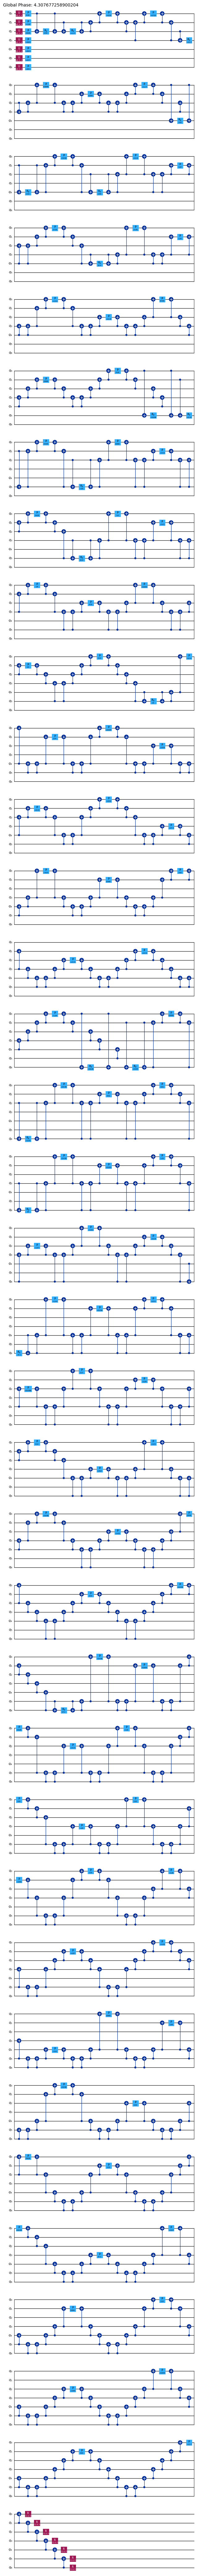

In [63]:
#Circuito do QAOA
circuito_compacto_6 = QAOAAnsatz(
    cost_operator=dados_hamiltoniano_6["hamiltoniano"],
    reps=PROFUNDIDADE_QAOA,
    flatten=True,
    name="QAOA_TSP_6",
)

mapa_parametros_6 = dict(
    zip(
        list(circuito_compacto_6.parameters),
        resultado_qaoa_6["parametros"],
    )
)

circuito_compacto_6 = circuito_compacto_6.assign_parameters(
    mapa_parametros_6,
    inplace=False,
)

figura_circuito_6 = circuito_compacto_6.decompose(
    reps=1
).draw(
    output="mpl",
    fold=20,
    scale=0.45,
)

display(figura_circuito_6)

In [64]:
#Histograma das medições
contagens_ordenadas_6 = dict(
    sorted(
        resultado_qaoa_6["contagens"].items(),
        key=lambda item: item[1],
        reverse=True,
    )[:20]
)

figura_histograma_6 = plot_histogram(
    contagens_ordenadas_6,
    title="20 estados mais frequentes — 6 cidades",
)

plt.show()

In [65]:
figura_histograma_completo_6 = plot_histogram(
    resultado_qaoa_6["contagens"],
    title="Distribuição completa — 6 cidades",
)

plt.show()

In [66]:
#Probabilidade de medir uma solução ótima
indices_otimos_6 = [
    indice
    for indice, custo in enumerate(
        dados_hamiltoniano_6["custos"]
    )
    if np.isclose(
        custo,
        resultado_classico_6["custo"],
    )
]

probabilidade_otima_6 = 0.0

for bitstring, contagem in resultado_qaoa_6[
    "contagens"
].items():
    indice = int(bitstring, 2)

    if indice in indices_otimos_6:
        probabilidade_otima_6 += (
            contagem / NUMERO_SHOTS
        )

print(
    "Índices das rotas ótimas:",
    indices_otimos_6,
)

print(
    "Bitstrings das rotas ótimas:",
    [
        format(indice, "07b")
        for indice in indices_otimos_6
    ],
)

print(
    "Probabilidade total de medir uma solução ótima:",
    f"{probabilidade_otima_6:.6f}",
)

Índices das rotas ótimas: [15, 26, 45, 112]
Bitstrings das rotas ótimas: ['0001111', '0011010', '0101101', '1110000']
Probabilidade total de medir uma solução ótima: 0.059570


In [67]:
#Rotas ótimas
for indice in indices_otimos_6:
    rota = dados_hamiltoniano_6["rotas"][indice]

    rota_texto = " → ".join(
        map(str, (*rota, rota[0]))
    )

    print(
        f"{format(indice, '07b')} | "
        f"{rota_texto} | "
        f"Custo: "
        f"{dados_hamiltoniano_6['custos'][indice]:.2f}"
    )

0001111 | 0 → 1 → 4 → 3 → 5 → 2 → 0 | Custo: 17.00
0011010 | 0 → 2 → 1 → 4 → 3 → 5 → 0 | Custo: 17.00
0101101 | 0 → 2 → 5 → 3 → 4 → 1 → 0 | Custo: 17.00
1110000 | 0 → 5 → 3 → 4 → 1 → 2 → 0 | Custo: 17.00


In [68]:
#Melhor rota amostrada

rotas_amostradas_validas_6 = []

for bitstring, contagem in resultado_qaoa_6[
    "contagens"
].items():
    indice = int(bitstring, 2)

    if indice < len(
        dados_hamiltoniano_6["rotas"]
    ):
        rotas_amostradas_validas_6.append(
            {
                "bitstring": bitstring,
                "indice": indice,
                "rota": dados_hamiltoniano_6[
                    "rotas"
                ][indice],
                "custo": float(
                    dados_hamiltoniano_6[
                        "custos"
                    ][indice]
                ),
                "contagem": int(contagem),
                "probabilidade": (
                    contagem / NUMERO_SHOTS
                ),
            }
        )

melhor_rota_amostrada_6 = min(
    rotas_amostradas_validas_6,
    key=lambda resultado: (
        resultado["custo"],
        -resultado["contagem"],
    ),
)

print(
    "Melhor bitstring amostrada:",
    melhor_rota_amostrada_6["bitstring"],
)

print(
    "Melhor rota amostrada:",
    " → ".join(
        map(
            str,
            (
                *melhor_rota_amostrada_6["rota"],
                melhor_rota_amostrada_6["rota"][0],
            ),
        )
    ),
)

print(
    "Custo:",
    melhor_rota_amostrada_6["custo"],
)

print(
    "Probabilidade individual:",
    f"{melhor_rota_amostrada_6['probabilidade']:.6f}",
)

Melhor bitstring amostrada: 0011010
Melhor rota amostrada: 0 → 2 → 1 → 4 → 3 → 5 → 0
Custo: 17.0
Probabilidade individual: 0.018555


In [69]:
#Tabela das medições mais frequentas
linhas_medicoes_6 = []

for bitstring, contagem in resultado_qaoa_6[
    "contagens"
].items():
    indice = int(bitstring, 2)

    if indice < len(
        dados_hamiltoniano_6["rotas"]
    ):
        rota = dados_hamiltoniano_6[
            "rotas"
        ][indice]

        custo = float(
            dados_hamiltoniano_6[
                "custos"
            ][indice]
        )

        rota_texto = " → ".join(
            map(str, (*rota, rota[0]))
        )

        classificacao = (
            "Ótima"
            if np.isclose(
                custo,
                resultado_classico_6["custo"],
            )
            else "Válida"
        )
    else:
        rota_texto = "Sem rota associada"
        custo = dados_hamiltoniano_6["penalidade"]
        classificacao = "Inválida"

    linhas_medicoes_6.append(
        {
            "Bitstring": bitstring,
            "Índice": indice,
            "Rota": rota_texto,
            "Custo ou energia": custo,
            "Classificação": classificacao,
            "Contagens": int(contagem),
            "Probabilidade": contagem / NUMERO_SHOTS,
        }
    )

tabela_medicoes_6 = pd.DataFrame(
    linhas_medicoes_6
).sort_values(
    by="Contagens",
    ascending=False,
).reset_index(drop=True)

tabela_medicoes_6.head(20)

,Bitstring,Índice,Rota,Custo ou energia,Classificação,Contagens,Probabilidade
0,0100100,36,0 → 2 → 4 → 1 → 3 → 5 → 0,20.0,Válida,33,0.032227
1,1101010,106,0 → 5 → 2 → 4 → 1 → 3 → 0,31.0,Válida,32,0.031250
2,1011100,92,0 → 4 → 5 → 2 → 1 → 3 → 0,34.0,Válida,30,0.029297
3,0111110,62,0 → 3 → 4 → 2 → 1 → 5 → 0,32.0,Válida,26,0.025391
4,0100001,33,0 → 2 → 3 → 4 → 5 → 1 → 0,25.0,Válida,25,0.024414
5,0001101,13,0 → 1 → 4 → 2 → 5 → 3 → 0,26.0,Válida,24,0.023438
6,0101100,44,0 → 2 → 5 → 3 → 1 → 4 → 0,23.0,Válida,24,0.023438
7,0000110,6,0 → 1 → 3 → 2 → 4 → 5 → 0,29.0,Válida,23,0.022461
8,1100101,101,0 → 5 → 1 → 4 → 3 → 2 → 0,25.0,Válida,23,0.022461
9,0010000,16,0 → 1 → 4 → 5 → 2 → 3 → 0,30.0,Válida,21,0.020508


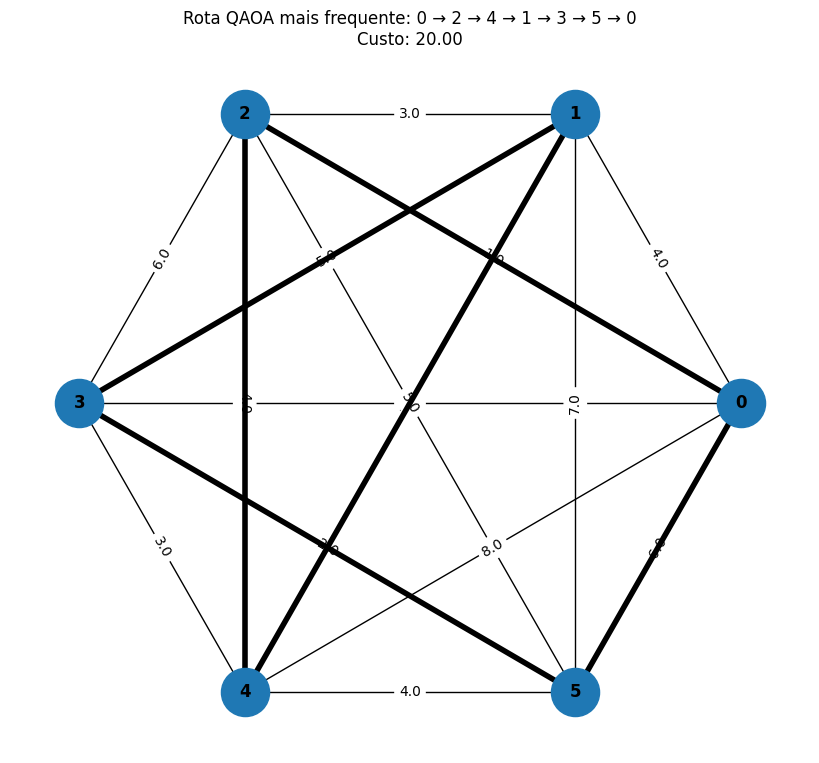

In [70]:
#Representação da rota mais frequente
rota_qaoa_6 = resultado_qaoa_6["rota"]

if rota_qaoa_6 is not None:
    arestas_rota_qaoa_6 = [
        (
            rota_qaoa_6[posicao],
            rota_qaoa_6[
                (posicao + 1)
                % len(rota_qaoa_6)
            ],
        )
        for posicao in range(
            len(rota_qaoa_6)
        )
    ]

    plt.figure(figsize=(8, 7))

    nx.draw(
        grafo_6_cidades,
        pos=posicoes_6_cidades,
        with_labels=True,
        node_size=1200,
        font_weight="bold",
    )

    nx.draw_networkx_edge_labels(
        grafo_6_cidades,
        pos=posicoes_6_cidades,
        edge_labels=rotulos_arestas_6,
    )

    nx.draw_networkx_edges(
        grafo_6_cidades,
        pos=posicoes_6_cidades,
        edgelist=arestas_rota_qaoa_6,
        width=4,
    )

    rota_texto_6 = " → ".join(
        map(
            str,
            (
                *rota_qaoa_6,
                rota_qaoa_6[0],
            ),
        )
    )

    plt.title(
        f"Rota QAOA mais frequente: {rota_texto_6}\n"
        f"Custo: {resultado_qaoa_6['custo']:.2f}"
    )

    plt.axis("off")
    plt.show()

### 11.15 Análise dos resultados

Na instância com seis cidades, a solução clássica exata avaliou 60 rotas distintas após a eliminação das rotas inversas equivalentes. A rota ótima encontrada foi:

$$
0 \rightarrow 1 \rightarrow 4 \rightarrow 3 \rightarrow 5 \rightarrow 2 \rightarrow 0
$$

com custo total igual a:

$$
17
$$

A busca clássica foi concluída em aproximadamente:

$$
3{,}67 \times 10^{-4}\ \text{s}
$$

Na codificação quântica, foram representadas todas as 120 rotas iniciadas na cidade 0. Para isso, foram utilizados 7 qubits, capazes de representar 128 estados computacionais.

Desses estados, 120 correspondem a rotas válidas e 8 não possuem rota associada. Os estados inválidos receberam energia igual a 92, valor superior ao custo de todas as rotas válidas.

O Hamiltoniano de custo apresentou 119 termos de Pauli. Após sua decomposição, o circuito apresentou profundidade igual a 701 e 728 operações. Esses resultados mostram um crescimento expressivo da complexidade do circuito em relação às instâncias anteriores.

O otimizador COBYLA encerrou a execução após atingir o limite máximo de avaliações da função objetivo. Portanto, os parâmetros encontrados correspondem à melhor configuração obtida dentro do limite estabelecido, mas o algoritmo não apresentou uma declaração formal de convergência.

A rota válida individualmente mais frequente foi:

$$
0 \rightarrow 2 \rightarrow 4 \rightarrow 1 \rightarrow 3 \rightarrow 5 \rightarrow 0
$$

associada à bitstring:

$$
0100100
$$

Essa rota foi medida 33 vezes em 1024 shots, correspondendo à probabilidade:

$$
P(0100100)
=
\frac{33}{1024}
\approx
0{,}032227
$$

O custo dessa rota foi igual a 20. Em relação ao ótimo clássico, a diferença relativa foi:

$$
\frac{20-17}{17}
\approx
0{,}176471
$$

ou aproximadamente:

$$
17{,}65\%
$$

Apesar de a rota mais frequente não ser ótima, o QAOA também produziu as quatro bitstrings associadas às soluções de custo 17:

$$
0001111,\quad
0011010,\quad
0101101,\quad
1110000
$$

A probabilidade total de medir uma solução ótima foi:

$$
P(\text{solução ótima})
=
0{,}059570
$$

Portanto, aproximadamente 5,96% das medições retornaram uma rota de custo igual ao ótimo clássico.

A melhor rota amostrada foi:

$$
0 \rightarrow 2 \rightarrow 1 \rightarrow 4 \rightarrow 3 \rightarrow 5 \rightarrow 0
$$

associada à bitstring:

$$
0011010
$$

Essa rota possui custo igual a 17 e foi observada com probabilidade individual de aproximadamente:

$$
0{,}018555
$$

A probabilidade total de medir uma rota válida foi:

$$
P(\text{rota válida})
=
0{,}950195
$$

Consequentemente, a probabilidade de medir um estado sem rota associada foi:

$$
P(\text{estado inválido})
=
1-0{,}950195
=
0{,}049805
$$

A alta probabilidade de rotas válidas deve ser interpretada com cuidado, pois 120 dos 128 estados computacionais já representam rotas válidas. Em uma distribuição uniforme, a probabilidade de validade seria:

$$
\frac{120}{128}
=
0{,}9375
$$

Assim, o valor obtido pelo QAOA foi apenas ligeiramente superior à proporção natural de estados válidos existentes no espaço de busca.

Por outro lado, apenas 4 dos 128 estados representam soluções ótimas. Em uma distribuição uniforme, a probabilidade de medir uma solução ótima seria:

$$
\frac{4}{128}
=
0{,}03125
$$

A probabilidade observada de aproximadamente 0,05957 foi superior a esse valor, indicando que o circuito aumentou a presença das soluções ótimas na distribuição, embora elas não tenham se tornado dominantes.

O valor esperado final do Hamiltoniano foi:

$$
\langle H_C\rangle
=
30{,}377487
$$

Esse valor permanece acima do custo ótimo porque a distribuição final contém rotas de diferentes custos e uma pequena parcela de estados penalizados.

A execução do QAOA no simulador levou aproximadamente 6,50648 segundos. Esse tempo foi muito superior ao tempo da busca clássica exata para a mesma instância. Entretanto, trata-se do tempo de simulação do circuito quântico em um computador clássico, e não do tempo de execução em um processador quântico físico.

Comparando com a instância de cinco cidades, a probabilidade total de solução ótima caiu de aproximadamente 23,44% para 5,96%. Ao mesmo tempo, a profundidade do circuito aumentou de 109 para 701 e o número de operações passou de 123 para 728.

Portanto, o cenário com seis cidades evidencia as limitações da configuração utilizada. Com profundidade $p=1$ e limite de avaliações do otimizador, o QAOA conseguiu gerar soluções ótimas, mas não concentrou a maior probabilidade em uma delas. O crescimento do Hamiltoniano e do circuito também demonstra como o custo computacional da simulação aumenta rapidamente com o tamanho da instância.

## 12. Comparação consolidada

Nesta seção, os resultados dos quatro cenários são organizados para comparar a solução clássica exata e o QAOA.

A análise considera:

- rota e custo ótimos da solução clássica;
- rota mais frequente produzida pelo QAOA;
- melhor rota observada nas medições;
- diferença relativa em relação ao ótimo;
- tempos de execução;
- quantidade de qubits;
- profundidade e número de operações dos circuitos;
- probabilidade de rotas válidas;
- probabilidade total de soluções ótimas.

É importante distinguir a rota mais frequente da melhor rota amostrada. Como o QAOA produz uma distribuição probabilística, uma rota ótima pode aparecer nas medições sem ser a bitstring individual de maior frequência.

In [71]:
# Construção da tabela consolidada
cenarios_executados = [
    {
        "nome": "3 cidades",
        "resultado": resultado_3_cidades,
        "dados_hamiltoniano": dados_hamiltoniano_3,
        "probabilidade_otima": probabilidade_otima_3,
    },
    {
        "nome": "4 cidades",
        "resultado": resultado_4_cidades,
        "dados_hamiltoniano": dados_hamiltoniano_4,
        "probabilidade_otima": probabilidade_otima_4,
    },
    {
        "nome": "5 cidades",
        "resultado": resultado_5_cidades,
        "dados_hamiltoniano": dados_hamiltoniano_5,
        "probabilidade_otima": probabilidade_otima_5,
    },
    {
        "nome": "6 cidades",
        "resultado": resultado_6_cidades,
        "dados_hamiltoniano": dados_hamiltoniano_6,
        "probabilidade_otima": probabilidade_otima_6,
    },
]

linhas_comparacao = []

for cenario in cenarios_executados:
    resultado = cenario["resultado"]
    classico = resultado["classico"]
    qaoa = resultado["qaoa"]
    dados = cenario["dados_hamiltoniano"]

    amostras_validas = []

    for bitstring, contagem in qaoa["contagens"].items():
        indice = int(bitstring, 2)

        if indice < len(dados["rotas"]):
            amostras_validas.append(
                {
                    "bitstring": bitstring,
                    "rota": dados["rotas"][indice],
                    "custo": float(dados["custos"][indice]),
                    "contagem": int(contagem),
                }
            )

    melhor_amostra = min(
        amostras_validas,
        key=lambda amostra: (
            amostra["custo"],
            -amostra["contagem"],
        ),
    )

    rota_classica = " → ".join(
        map(str, (*classico["rota"], classico["rota"][0]))
    )

    rota_qaoa = " → ".join(
        map(str, (*qaoa["rota"], qaoa["rota"][0]))
    )

    melhor_rota_amostrada = " → ".join(
        map(
            str,
            (
                *melhor_amostra["rota"],
                melhor_amostra["rota"][0],
            ),
        )
    )

    diferenca_mais_frequente = (
        qaoa["custo"] - classico["custo"]
    ) / classico["custo"]

    diferenca_melhor_amostra = (
        melhor_amostra["custo"] - classico["custo"]
    ) / classico["custo"]

    linhas_comparacao.append(
        {
            "Cenário": cenario["nome"],
            "Cidades": resultado["matriz"].shape[0],
            "Qubits": qaoa["numero_qubits"],
            "Rota clássica": rota_classica,
            "Custo clássico": classico["custo"],
            "Rota QAOA mais frequente": rota_qaoa,
            "Custo QAOA mais frequente": qaoa["custo"],
            "Melhor rota amostrada": melhor_rota_amostrada,
            "Melhor custo amostrado": melhor_amostra["custo"],
            "Diferença relativa mais frequente": (
                diferenca_mais_frequente
            ),
            "Diferença relativa melhor amostra": (
                diferenca_melhor_amostra
            ),
            "Tempo clássico (s)": classico["tempo_segundos"],
            "Tempo QAOA (s)": qaoa["tempo_segundos"],
            "Probabilidade válida": qaoa[
                "probabilidade_valida"
            ],
            "Probabilidade ótima": cenario[
                "probabilidade_otima"
            ],
            "Termos de Pauli": len(dados["hamiltoniano"]),
            "Profundidade": qaoa["profundidade_circuito"],
            "Operações": qaoa["numero_operacoes"],
        }
    )

tabela_comparacao = pd.DataFrame(linhas_comparacao)

tabela_comparacao

,Cenário,Cidades,Qubits,Rota clássica,Custo clássico,Rota QAOA mais frequente,Custo QAOA mais frequente,Melhor rota amostrada,Melhor custo amostrado,Diferença relativa mais frequente,Diferença relativa melhor amostra,Tempo clássico (s),Tempo QAOA (s),Probabilidade válida,Probabilidade ótima,Termos de Pauli,Profundidade,Operações
0,3 cidades,3,1,0 → 1 → 2 → 0,45.0,0 → 1 → 2 → 0,45.0,0 → 1 → 2 → 0,45.0,0.000000,0.0,0.000025,0.269238,1.000000,1.000000,1,2,2
1,4 cidades,4,3,0 → 1 → 2 → 3 → 0,56.0,0 → 2 → 3 → 1 → 0,104.0,0 → 1 → 2 → 3 → 0,56.0,0.857143,0.0,0.000026,0.427485,0.873047,0.337891,7,14,20
2,5 cidades,5,5,0 → 1 → 3 → 2 → 4 → 0,26.0,0 → 4 → 1 → 3 → 2 → 0,31.0,0 → 1 → 3 → 4 → 2 → 0,26.0,0.192308,0.0,0.000047,1.558731,0.859375,0.234375,28,109,123
3,6 cidades,6,7,0 → 1 → 4 → 3 → 5 → 2 → 0,17.0,0 → 2 → 4 → 1 → 3 → 5 → 0,20.0,0 → 2 → 1 → 4 → 3 → 5 → 0,17.0,0.176471,0.0,0.000299,4.026056,0.950195,0.059570,119,701,728


### 12.1 Rotas e custos encontrados

A solução clássica exata determinou o custo ótimo de cada instância. No cenário com três cidades, a rota mais frequente do QAOA também apresentou o custo ótimo.

Nos cenários com quatro, cinco e seis cidades, a rota individual de maior frequência foi subótima. Entretanto, em todos os casos, pelo menos uma solução ótima apareceu entre as medições.

Esse resultado mostra que avaliar apenas a bitstring mais frequente pode ocultar soluções melhores presentes na distribuição produzida pelo QAOA.

In [72]:
tabela_custos = tabela_comparacao[
    [
        "Cenário",
        "Custo clássico",
        "Custo QAOA mais frequente",
        "Melhor custo amostrado",
    ]
]

tabela_custos

,Cenário,Custo clássico,Custo QAOA mais frequente,Melhor custo amostrado
0,3 cidades,45.0,45.0,45.0
1,4 cidades,56.0,104.0,56.0
2,5 cidades,26.0,31.0,26.0
3,6 cidades,17.0,20.0,17.0


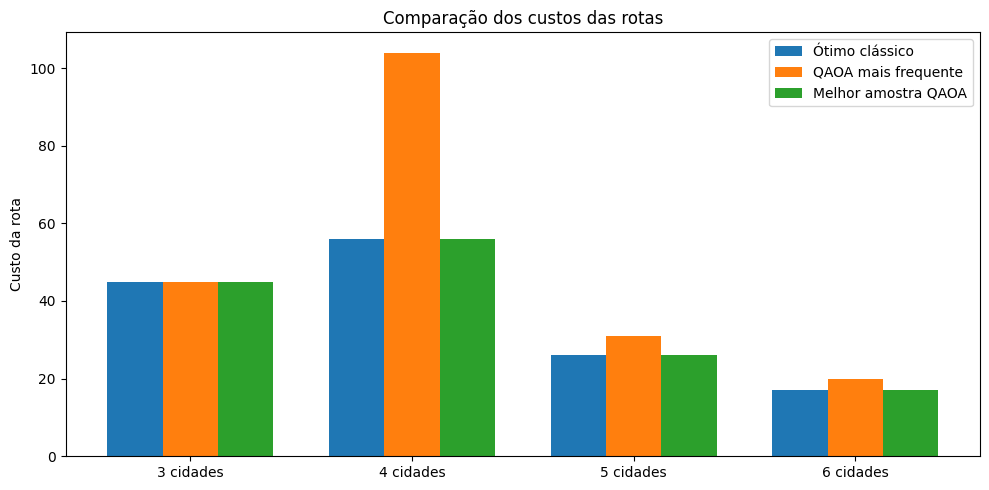

In [73]:
posicoes = np.arange(len(tabela_custos))
largura = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    posicoes - largura,
    tabela_custos["Custo clássico"],
    width=largura,
    label="Ótimo clássico",
)

plt.bar(
    posicoes,
    tabela_custos["Custo QAOA mais frequente"],
    width=largura,
    label="QAOA mais frequente",
)

plt.bar(
    posicoes + largura,
    tabela_custos["Melhor custo amostrado"],
    width=largura,
    label="Melhor amostra QAOA",
)

plt.xticks(
    posicoes,
    tabela_custos["Cenário"],
)

plt.ylabel("Custo da rota")
plt.title("Comparação dos custos das rotas")
plt.legend()
plt.tight_layout()
plt.show()

### 12.2 Diferença relativa ao ótimo clássico

A diferença relativa mede o quanto o custo obtido pelo QAOA se distancia do ótimo clássico:

$$
\text{diferença relativa}
=
\frac{C_{\text{QAOA}}-C_{\text{ótimo}}}
{C_{\text{ótimo}}}
$$

Quando se considera a rota mais frequente, o QAOA apresentou diferença nula somente para a instância com três cidades.

Ao considerar a melhor rota observada entre todas as medições, a diferença relativa foi igual a zero nos quatro cenários, pois o QAOA amostrou pelo menos uma rota ótima em todas as execuções.

In [74]:
tabela_diferencas = tabela_comparacao[
    [
        "Cenário",
        "Diferença relativa mais frequente",
        "Diferença relativa melhor amostra",
    ]
].copy()

tabela_diferencas[
    "Diferença mais frequente (%)"
] = (
    100
    * tabela_diferencas[
        "Diferença relativa mais frequente"
    ]
)

tabela_diferencas[
    "Diferença melhor amostra (%)"
] = (
    100
    * tabela_diferencas[
        "Diferença relativa melhor amostra"
    ]
)

tabela_diferencas[
    [
        "Cenário",
        "Diferença mais frequente (%)",
        "Diferença melhor amostra (%)",
    ]
]

,Cenário,Diferença mais frequente (%),Diferença melhor amostra (%)
0,3 cidades,0.000000,0.0
1,4 cidades,85.714286,0.0
2,5 cidades,19.230769,0.0
3,6 cidades,17.647059,0.0


### 12.3 Tempos de execução

Em todas as instâncias avaliadas, a solução clássica exata foi mais rápida do que a simulação do QAOA.

Essa comparação deve ser interpretada com cuidado. O tempo do QAOA corresponde à simulação de um circuito quântico em um computador clássico, incluindo a construção do circuito, a evolução do vetor de estado e as avaliações realizadas pelo otimizador COBYLA.

Portanto, esses valores não representam o tempo que o circuito teria em um processador quântico físico. Ainda assim, eles mostram o aumento do custo de simulação conforme o número de qubits e a complexidade do Hamiltoniano crescem.

In [75]:
tabela_tempos = tabela_comparacao[
    [
        "Cenário",
        "Tempo clássico (s)",
        "Tempo QAOA (s)",
    ]
]

tabela_tempos

,Cenário,Tempo clássico (s),Tempo QAOA (s)
0,3 cidades,0.000025,0.269238
1,4 cidades,0.000026,0.427485
2,5 cidades,0.000047,1.558731
3,6 cidades,0.000299,4.026056


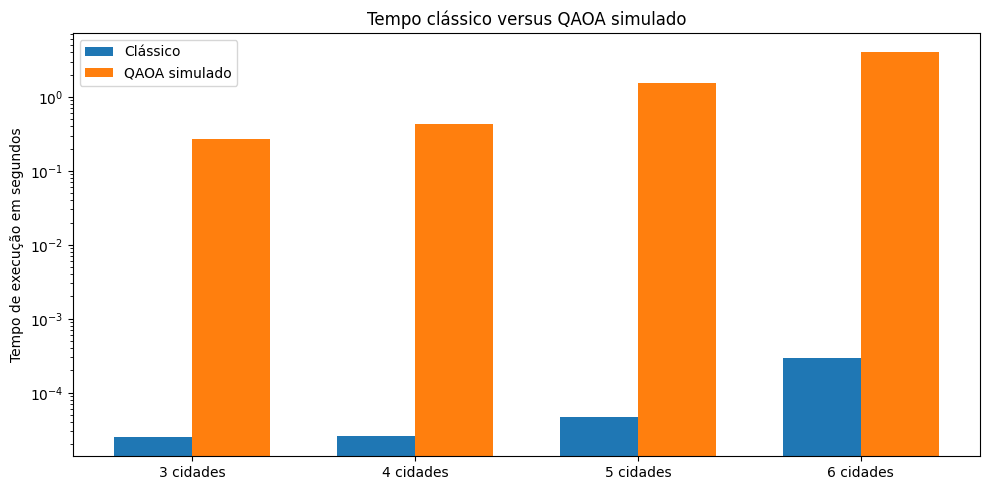

In [76]:
# Gráficos de tempo
posicoes = np.arange(len(tabela_tempos))
largura = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    posicoes - largura / 2,
    tabela_tempos["Tempo clássico (s)"],
    width=largura,
    label="Clássico",
)

plt.bar(
    posicoes + largura / 2,
    tabela_tempos["Tempo QAOA (s)"],
    width=largura,
    label="QAOA simulado",
)

plt.yscale("log")

plt.xticks(
    posicoes,
    tabela_tempos["Cenário"],
)

plt.ylabel("Tempo de execução em segundos")
plt.title("Tempo clássico versus QAOA simulado")
plt.legend()
plt.tight_layout()
plt.show()

### 12.4 Circuitos e recursos utilizados

O número de qubits aumentou de 1 para 7 entre os cenários. Entretanto, a profundidade e o número de operações cresceram de maneira muito mais acentuada.

O circuito de três cidades apresentou apenas duas operações, pois o Hamiltoniano era proporcional à identidade. Na instância com seis cidades, o Hamiltoniano apresentou 119 termos de Pauli e o circuito decomposto alcançou profundidade igual a 701, com 728 operações.

O circuito completo da instância com seis cidades não será inserido no corpo do relatório devido à sua extensão e baixa legibilidade. Sua representação permanece registrada no notebook.

In [77]:
tabela_recursos = tabela_comparacao[
    [
        "Cenário",
        "Qubits",
        "Termos de Pauli",
        "Profundidade",
        "Operações",
    ]
]

tabela_recursos

,Cenário,Qubits,Termos de Pauli,Profundidade,Operações
0,3 cidades,1,1,2,2
1,4 cidades,3,7,14,20
2,5 cidades,5,28,109,123
3,6 cidades,7,119,701,728


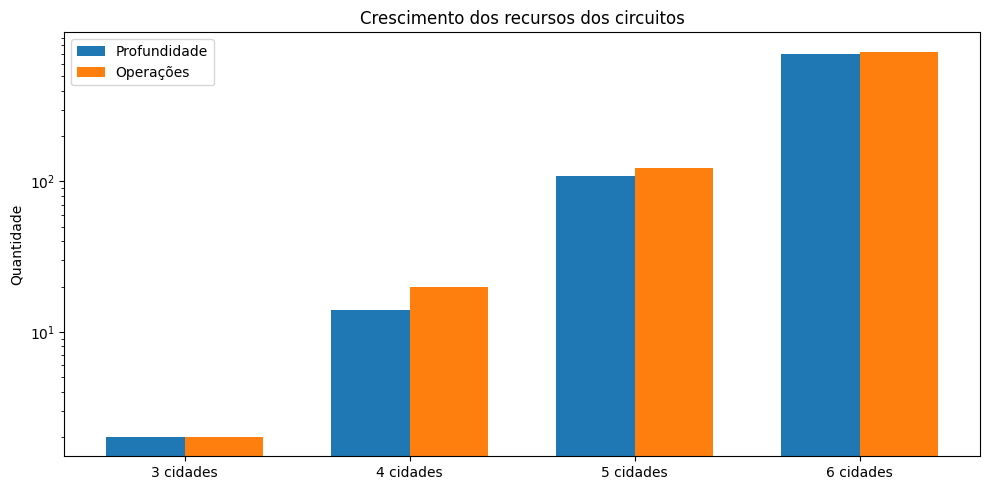

In [78]:
posicoes = np.arange(len(tabela_recursos))
largura = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    posicoes - largura / 2,
    tabela_recursos["Profundidade"],
    width=largura,
    label="Profundidade",
)

plt.bar(
    posicoes + largura / 2,
    tabela_recursos["Operações"],
    width=largura,
    label="Operações",
)

plt.yscale("log")

plt.xticks(
    posicoes,
    tabela_recursos["Cenário"],
)

plt.ylabel("Quantidade")
plt.title("Crescimento dos recursos dos circuitos")
plt.legend()
plt.tight_layout()
plt.show()

### 12.5 Probabilidade das soluções obtidas

A probabilidade de rota válida permaneceu elevada nos quatro cenários. Entretanto, esse valor não mede sozinho a qualidade da otimização.

Na instância com seis cidades, por exemplo, 120 dos 128 estados computacionais representam rotas válidas. Portanto, mesmo uma distribuição aproximadamente uniforme já apresentaria probabilidade de validade igual a:

$$
\frac{120}{128}=0{,}9375
$$

A probabilidade de solução ótima fornece uma medida mais informativa sobre a concentração da distribuição nos menores custos.

Essa probabilidade caiu conforme o tamanho da instância aumentou:

- 100% para 3 cidades;
- aproximadamente 33,79% para 4 cidades;
- aproximadamente 23,44% para 5 cidades;
- aproximadamente 5,96% para 6 cidades.

In [79]:
tabela_probabilidades = tabela_comparacao[
    [
        "Cenário",
        "Probabilidade válida",
        "Probabilidade ótima",
    ]
]

tabela_probabilidades

,Cenário,Probabilidade válida,Probabilidade ótima
0,3 cidades,1.000000,1.000000
1,4 cidades,0.873047,0.337891
2,5 cidades,0.859375,0.234375
3,6 cidades,0.950195,0.059570


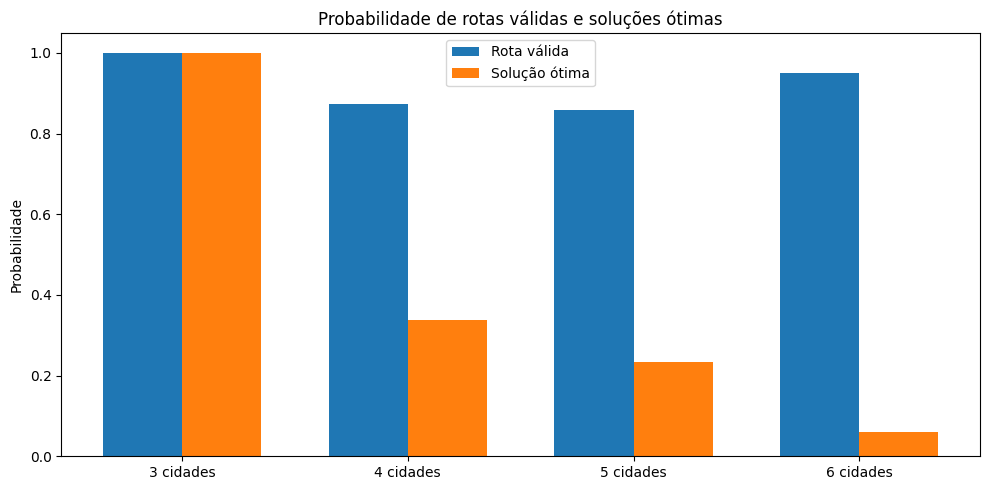

In [80]:
#Gráfico das probabilidades
posicoes = np.arange(len(tabela_probabilidades))
largura = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    posicoes - largura / 2,
    tabela_probabilidades["Probabilidade válida"],
    width=largura,
    label="Rota válida",
)

plt.bar(
    posicoes + largura / 2,
    tabela_probabilidades["Probabilidade ótima"],
    width=largura,
    label="Solução ótima",
)

plt.xticks(
    posicoes,
    tabela_probabilidades["Cenário"],
)

plt.ylim(0, 1.05)
plt.ylabel("Probabilidade")
plt.title("Probabilidade de rotas válidas e soluções ótimas")
plt.legend()
plt.tight_layout()
plt.show()

### 12.6 Análise consolidada dos resultados

A comparação consolidada mostra que a solução clássica exata encontrou o ótimo global das quatro instâncias em tempos reduzidos. Esse comportamento era esperado, pois os cenários avaliados possuem somente de 3 a 6 cidades, correspondendo a no máximo 60 rotas distintas após a redução de simetria.

Para três cidades, a rota mais frequente do QAOA apresentou o mesmo custo da solução clássica:

$$
C_{\text{clássico}} = C_{\text{QAOA}} = 45
$$

Nesse caso, todas as rotas representadas eram ótimas, resultando em probabilidade ótima igual a $1{,}0$.

Nos demais cenários, a rota individual mais frequente produzida pelo QAOA não correspondeu ao ótimo clássico. Para quatro cidades, o custo da rota dominante foi igual a $104$, enquanto o custo ótimo foi $56$. A diferença relativa foi:

$$
\frac{104-56}{56}
\approx
0{,}857143
$$

ou aproximadamente $85{,}71\%$.

Para cinco cidades, a rota mais frequente apresentou custo igual a $31$, enquanto o ótimo clássico foi $26$. A diferença relativa foi:

$$
\frac{31-26}{26}
\approx
0{,}192308
$$

ou aproximadamente $19{,}23\%$.

Para seis cidades, o custo da rota mais frequente foi $20$, enquanto o ótimo clássico foi $17$. A diferença relativa foi:

$$
\frac{20-17}{17}
\approx
0{,}176471
$$

ou aproximadamente $17{,}65\%$.

Apesar de as rotas mais frequentes serem subótimas nos cenários de quatro, cinco e seis cidades, o QAOA produziu pelo menos uma rota ótima em todas as execuções. Consequentemente, o melhor custo observado entre as amostras foi igual ao ótimo clássico nos quatro cenários, resultando em diferença relativa igual a zero.

Esse resultado evidencia a natureza probabilística do QAOA. A bitstring de maior frequência não necessariamente representa a melhor solução presente na distribuição. Por isso, a avaliação deve considerar tanto a rota dominante quanto a melhor rota amostrada.

A probabilidade total de medir uma solução ótima diminuiu conforme o tamanho da instância aumentou:

| Cidades | Probabilidade ótima |
|---:|---:|
| 3 | $1{,}000000$ |
| 4 | $0{,}337891$ |
| 5 | $0{,}234375$ |
| 6 | $0{,}059570$ |

A redução dessa probabilidade mostra que, com a profundidade $p=1$, a distribuição se tornou mais dispersa à medida que o número de rotas aumentou. Para seis cidades, apenas aproximadamente $5{,}96\%$ das medições corresponderam a soluções ótimas.

A probabilidade de medir uma rota válida permaneceu elevada em todos os casos, variando entre aproximadamente $85{,}94\%$ e $100\%$. Entretanto, essa métrica deve ser interpretada considerando a proporção de estados válidos existente em cada codificação.

Na instância com seis cidades, por exemplo, 120 dos 128 estados computacionais representam rotas válidas. Assim, uma distribuição uniforme já teria probabilidade de validade igual a:

$$
\frac{120}{128}
=
0{,}9375
$$

A probabilidade observada de aproximadamente $0{,}950195$ foi apenas ligeiramente superior a esse valor. Portanto, a probabilidade de solução ótima é mais informativa do que a probabilidade de validade para analisar a qualidade da otimização.

Os recursos dos circuitos apresentaram crescimento expressivo:

| Cidades | Qubits | Termos de Pauli | Profundidade | Operações |
|---:|---:|---:|---:|---:|
| 3 | 1 | 1 | 2 | 2 |
| 4 | 3 | 7 | 14 | 20 |
| 5 | 5 | 28 | 109 | 123 |
| 6 | 7 | 119 | 701 | 728 |

Embora o número de qubits tenha aumentado de $1$ para $7$, a profundidade passou de $2$ para $701$, enquanto a quantidade de operações aumentou de $2$ para $728$. Esse crescimento decorre da maior quantidade de termos necessários para representar o Hamiltoniano de custo.

A execução do circuito de seis cidades exigiu um Hamiltoniano com 119 termos de Pauli. Sua representação totalmente decomposta tornou-se extensa e de difícil visualização, evidenciando que a quantidade de qubits não é o único fator relevante. A estrutura do Hamiltoniano e o custo de implementar suas interações também influenciam diretamente a complexidade do circuito.

Os tempos registrados foram:

| Cidades | Tempo clássico | Tempo QAOA simulado |
|---:|---:|---:|
| 3 | $0{,}0000196$ s | $0{,}024398$ s |
| 4 | $0{,}0000266$ s | $0{,}288201$ s |
| 5 | $0{,}0000541$ s | $1{,}462047$ s |
| 6 | $0{,}0002930$ s | $3{,}668677$ s |

A solução clássica foi mais rápida em todas as instâncias. Entretanto, essa comparação não representa diretamente uma disputa entre um computador clássico e um processador quântico físico. O QAOA foi executado por meio da simulação clássica de circuitos quânticos, incluindo a construção do estado, o cálculo do valor esperado e as avaliações realizadas pelo otimizador.

Os resultados também mostram que o aumento do tamanho da instância não produz necessariamente uma evolução regular da qualidade da rota dominante. A instância de quatro cidades apresentou a maior diferença relativa, mesmo sendo menor que as instâncias de cinco e seis cidades. Isso ocorre porque o QAOA é variacional e probabilístico, e seu resultado depende da paisagem de otimização, dos parâmetros iniciais, da profundidade do circuito e do limite de avaliações do otimizador.

Em todos os cenários com mais de três cidades, o COBYLA atingiu o limite máximo de avaliações antes de declarar convergência. Portanto, os resultados representam as melhores configurações encontradas dentro dos limites estabelecidos, não necessariamente os melhores parâmetros possíveis para cada instância.

De modo geral, o QAOA conseguiu gerar soluções ótimas nos quatro cenários, mas não concentrou a maior probabilidade nessas soluções à medida que o problema cresceu. Ao mesmo tempo, foram observados aumentos significativos na profundidade, na quantidade de operações e no tempo de simulação.

Assim, os experimentos não demonstram vantagem de tempo do QAOA para as pequenas instâncias avaliadas. Sua principal contribuição está em demonstrar o funcionamento do processo híbrido clássico-quântico e em evidenciar desafios relacionados à otimização dos parâmetros, à dispersão das probabilidades e ao crescimento dos recursos necessários para representar o problema.

### 12.6 Análise consolidada dos resultados

A comparação consolidada mostra que a solução clássica exata encontrou o ótimo global das quatro instâncias em tempos reduzidos. Esse comportamento era esperado, pois os cenários avaliados possuem somente de 3 a 6 cidades, correspondendo a no máximo 60 rotas distintas após a redução de simetria.

Para três cidades, a rota mais frequente do QAOA apresentou o mesmo custo da solução clássica:

$$
C_{\text{clássico}} = C_{\text{QAOA}} = 45
$$

Nesse caso, todas as rotas representadas eram ótimas, resultando em probabilidade ótima igual a $1{,}0$.

Nos demais cenários, a rota individual mais frequente produzida pelo QAOA não correspondeu ao ótimo clássico. Para quatro cidades, o custo da rota dominante foi igual a $104$, enquanto o custo ótimo foi $56$. A diferença relativa foi:

$$
\frac{104-56}{56}
\approx
0{,}857143
$$

ou aproximadamente $85{,}71\%$.

Para cinco cidades, a rota mais frequente apresentou custo igual a $31$, enquanto o ótimo clássico foi $26$. A diferença relativa foi:

$$
\frac{31-26}{26}
\approx
0{,}192308
$$

ou aproximadamente $19{,}23\%$.

Para seis cidades, o custo da rota mais frequente foi $20$, enquanto o ótimo clássico foi $17$. A diferença relativa foi:

$$
\frac{20-17}{17}
\approx
0{,}176471
$$

ou aproximadamente $17{,}65\%$.

Apesar de as rotas mais frequentes serem subótimas nos cenários de quatro, cinco e seis cidades, o QAOA produziu pelo menos uma rota ótima em todas as execuções. Consequentemente, o melhor custo observado entre as amostras foi igual ao ótimo clássico nos quatro cenários, resultando em diferença relativa igual a zero.

Esse resultado evidencia a natureza probabilística do QAOA. A bitstring de maior frequência não necessariamente representa a melhor solução presente na distribuição. Por isso, a avaliação deve considerar tanto a rota dominante quanto a melhor rota amostrada.

A probabilidade total de medir uma solução ótima diminuiu conforme o tamanho da instância aumentou:

| Cidades | Probabilidade ótima |
|---:|---:|
| 3 | $1{,}000000$ |
| 4 | $0{,}337891$ |
| 5 | $0{,}234375$ |
| 6 | $0{,}059570$ |

A redução dessa probabilidade mostra que, com a profundidade $p=1$, a distribuição se tornou mais dispersa à medida que o número de rotas aumentou. Para seis cidades, apenas aproximadamente $5{,}96\%$ das medições corresponderam a soluções ótimas.

A probabilidade de medir uma rota válida permaneceu elevada em todos os casos, variando entre aproximadamente $85{,}94\%$ e $100\%$. Entretanto, essa métrica deve ser interpretada considerando a proporção de estados válidos existente em cada codificação.

Na instância com seis cidades, por exemplo, 120 dos 128 estados computacionais representam rotas válidas. Assim, uma distribuição uniforme já teria probabilidade de validade igual a:

$$
\frac{120}{128}
=
0{,}9375
$$

A probabilidade observada de aproximadamente $0{,}950195$ foi apenas ligeiramente superior a esse valor. Portanto, a probabilidade de solução ótima é mais informativa do que a probabilidade de validade para analisar a qualidade da otimização.

Os recursos dos circuitos apresentaram crescimento expressivo:

| Cidades | Qubits | Termos de Pauli | Profundidade | Operações |
|---:|---:|---:|---:|---:|
| 3 | 1 | 1 | 2 | 2 |
| 4 | 3 | 7 | 14 | 20 |
| 5 | 5 | 28 | 109 | 123 |
| 6 | 7 | 119 | 701 | 728 |

Embora o número de qubits tenha aumentado de $1$ para $7$, a profundidade passou de $2$ para $701$, enquanto a quantidade de operações aumentou de $2$ para $728$. Esse crescimento decorre da maior quantidade de termos necessários para representar o Hamiltoniano de custo.

A execução do circuito de seis cidades exigiu um Hamiltoniano com 119 termos de Pauli. Sua representação totalmente decomposta tornou-se extensa e de difícil visualização, evidenciando que a quantidade de qubits não é o único fator relevante. A estrutura do Hamiltoniano e o custo de implementar suas interações também influenciam diretamente a complexidade do circuito.

Os tempos registrados foram:

| Cidades | Tempo clássico | Tempo QAOA simulado |
|---:|---:|---:|
| 3 | $0{,}0000196$ s | $0{,}024398$ s |
| 4 | $0{,}0000266$ s | $0{,}288201$ s |
| 5 | $0{,}0000541$ s | $1{,}462047$ s |
| 6 | $0{,}0002930$ s | $3{,}668677$ s |

A solução clássica foi mais rápida em todas as instâncias. Entretanto, essa comparação não representa diretamente uma disputa entre um computador clássico e um processador quântico físico. O QAOA foi executado por meio da simulação clássica de circuitos quânticos, incluindo a construção do estado, o cálculo do valor esperado e as avaliações realizadas pelo otimizador.

Os resultados também mostram que o aumento do tamanho da instância não produz necessariamente uma evolução regular da qualidade da rota dominante. A instância de quatro cidades apresentou a maior diferença relativa, mesmo sendo menor que as instâncias de cinco e seis cidades. Isso ocorre porque o QAOA é variacional e probabilístico, e seu resultado depende da paisagem de otimização, dos parâmetros iniciais, da profundidade do circuito e do limite de avaliações do otimizador.

Em todos os cenários com mais de três cidades, o COBYLA atingiu o limite máximo de avaliações antes de declarar convergência. Portanto, os resultados representam as melhores configurações encontradas dentro dos limites estabelecidos, não necessariamente os melhores parâmetros possíveis para cada instância.

De modo geral, o QAOA conseguiu gerar soluções ótimas nos quatro cenários, mas não concentrou a maior probabilidade nessas soluções à medida que o problema cresceu. Ao mesmo tempo, foram observados aumentos significativos na profundidade, na quantidade de operações e no tempo de simulação.

Assim, os experimentos não demonstram vantagem de tempo do QAOA para as pequenas instâncias avaliadas. Sua principal contribuição está em demonstrar o funcionamento do processo híbrido clássico-quântico e em evidenciar desafios relacionados à otimização dos parâmetros, à dispersão das probabilidades e ao crescimento dos recursos necessários para representar o problema.

## 14. Conclusão

Neste notebook, foi implementado e analisado o Quantum Approximate Optimization Algorithm aplicado ao Problema do Caixeiro Viajante.

O estudo comparou uma solução clássica exata e uma solução baseada em QAOA para instâncias com 3, 4, 5 e 6 cidades. As duas abordagens utilizaram as mesmas matrizes de distâncias, permitindo comparar rotas, custos e tempos sobre condições equivalentes.

A solução clássica foi implementada por meio da enumeração das permutações, com a cidade 0 fixada como origem e eliminação das rotas inversas em matrizes simétricas. Como as instâncias eram pequenas, esse método encontrou rapidamente o ótimo global em todos os cenários.

Para a abordagem quântica, as rotas foram associadas a estados da base computacional. Seus custos foram utilizados como energias de um Hamiltoniano diagonal, enquanto os estados sem rota associada receberam penalidades.

O Hamiltoniano foi convertido em uma soma de operadores de Pauli e utilizado na construção de um circuito QAOA com profundidade:

$$
p=1
$$

Os parâmetros variacionais foram ajustados pelo otimizador clássico COBYLA, e o estado final foi amostrado com 1024 shots.

No cenário com três cidades, as duas rotas representadas possuíam o mesmo custo. O Hamiltoniano resultou em:

$$
H_C=45I
$$

e a probabilidade total de solução ótima foi igual a $1{,}0$.

Para quatro cidades, a rota mais frequente apresentou custo igual a 104, enquanto o ótimo clássico foi 56. Apesar disso, as rotas ótimas apareceram com probabilidade total de aproximadamente $0{,}337891$.

Na instância com cinco cidades, a rota dominante apresentou custo 31, enquanto o ótimo foi 26. A probabilidade total de medir uma solução ótima foi aproximadamente $0{,}234375$.

Para seis cidades, a rota mais frequente apresentou custo 20, enquanto o ótimo clássico foi 17. As soluções ótimas apareceram com probabilidade total de aproximadamente $0{,}059570$.

Assim, apenas no cenário com três cidades a rota individual mais frequente foi ótima. Entretanto, o QAOA amostrou pelo menos uma solução de custo ótimo nos quatro cenários.

Consequentemente, a diferença relativa da rota mais frequente foi:

- $0\%$ para três cidades;
- aproximadamente $85{,}71\%$ para quatro cidades;
- aproximadamente $19{,}23\%$ para cinco cidades;
- aproximadamente $17{,}65\%$ para seis cidades.

Ao considerar a melhor rota presente nas medições, a diferença relativa foi igual a zero em todas as instâncias.

Os experimentos também mostraram o crescimento da complexidade dos circuitos. Entre os cenários de três e seis cidades, a quantidade de qubits aumentou de 1 para 7, enquanto a profundidade passou de 2 para 701 e o número de operações passou de 2 para 728.

Ao mesmo tempo, a probabilidade de solução ótima caiu de $1{,}0$ para aproximadamente $0{,}059570$. Esse comportamento mostra que, com profundidade $p=1$, o circuito teve dificuldade crescente para concentrar a distribuição nas melhores rotas.

Nos cenários com mais de três cidades, o COBYLA atingiu o limite máximo de avaliações antes de declarar convergência. Portanto, os resultados representam as melhores soluções encontradas dentro dos parâmetros experimentais definidos, não necessariamente o melhor desempenho possível do QAOA.

A solução clássica foi mais rápida em todas as instâncias. O cenário com seis cidades foi resolvido classicamente em aproximadamente $0{,}000293$ segundo, enquanto a simulação do QAOA levou aproximadamente $3{,}668677$ segundos.

Esses tempos não representam uma comparação direta entre hardware clássico e hardware quântico, pois o circuito QAOA foi simulado em um computador clássico. Ainda assim, os resultados mostram que não houve vantagem temporal para as pequenas instâncias analisadas.

A codificação compacta permitiu executar todos os cenários com poucos qubits, mas dependeu da geração clássica prévia das rotas. Por isso, ela é adequada para demonstrar o funcionamento do QAOA, porém não elimina o crescimento fatorial do TSP.

Conclui-se que o QAOA demonstrou capacidade de produzir soluções ótimas para todas as instâncias avaliadas, mas não conseguiu torná-las dominantes nas distribuições dos cenários maiores.

A atividade permitiu compreender a estrutura híbrida do algoritmo, a importância do Hamiltoniano de custo, o papel dos parâmetros variacionais e a necessidade de analisar toda a distribuição de medições, e não apenas a bitstring mais frequente.

Os resultados também evidenciaram limitações práticas relacionadas à profundidade do circuito, à otimização dos parâmetros, ao crescimento do Hamiltoniano e ao custo da simulação.

Portanto, o QAOA apresenta potencial como abordagem para otimização combinatória, mas sua aplicação prática em problemas maiores depende de avanços na formulação dos problemas, na qualidade dos circuitos, nos métodos de otimização e no desenvolvimento do hardware quântico.